# Gulf of Oman STS vs Strait of Hormuz exits

Compare crude volume leaving the Strait of Hormuz (`soh_crossing_hist.xlsx` **Exited MEG**) with ship-to-ship activity in the Gulf of Oman region.

**Why:** some laden hulls exit SoH, go dark, then STS offshore (Fujairah Light / Sohar Light / Gulf of Oman). Separately, some cargo is **loaded** on the UAE east coast or Oman and never touches the strait — those loadings must be isolated for a fair SoH comparison.

**Important distinction**
- **STS zone** (Fujairah Light, Sohar Light, Gulf of Oman) = where the transfer happens → **keep all** of these.
- **Cargo origin** (ADCOP Fujairah, Sohar terminal, etc.) = where barrels were loaded → east-coast/Oman *loadings* are reported separately, not dropped from the STS map.

**Lag:** exit -> STS is often delayed (days to weeks). Matching uses `STS_LAG_DAYS`.

**Decision metric (§8c):** `unaccounted` volume vs reported SoH exits → count OK vs bearish cue.

**Unknown-partner STS:** ShipToShips only returns named↔named pairs. Transfers with an unknown mother (portal: *Ship-to-ship with unknown vessel*) appear in **PortCalls** (`is_sts=True`) / Trades instead — captured in a dedicated section.

**Journey traces:** `origin load -> SoH exit -> STS hop(s) -> final discharge` with barrels attributed once per exit.

Kpler: [Ship To Ships](https://python-sdk.dev.kpler.com/resources/ship_to_ships.html), [Trades](https://python-sdk.dev.kpler.com/resources/trades.html).


## 1. Setup & config


In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import date, timedelta
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 56)
pd.set_option("display.width", 180)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

BASE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing")
CROSSING_PATH = BASE / "soh_crossing_hist.xlsx"
AFRA_PATH = BASE / "afra_scale_mapping.xlsx"
ENV_PATH = BASE / ".env"

# Align with soh_crossing_analysis.ipynb
START_DATE = date(2026, 6, 17)
END_DATE = None  # None -> max Crossing Date in file

# How long after an SoH exit we still accept a regional STS as the same cargo leg.
STS_LAG_DAYS = 5

# Extend STS / trade pulls past the crossing window so late transfers still appear.
STS_LOOKAHEAD_DAYS = 5

# Max STS hops when walking A -> B -> C ...
MAX_STS_HOPS = 3

EXAMPLE_VESSEL = "ROTTERDAM ENERGY"
# Portal example: STS with unknown mother (absent from ShipToShips)
UNKNOWN_STS_EXAMPLE = "SANMAR HERALD"
# Match PortCalls is_sts to ShipToShips pairs within this window (days)
STS_PAIR_MATCH_DAYS = 3

# Kpler zone "Gulf of Oman" returns Fujairah Light. / Sohar Light. / Gulf of Oman rows — all kept.
STS_ZONES = [
    "Gulf of Oman",
]

# Cargo LOAD origins east of Hormuz (never need SoH). Used on Trades origins / last-cargo names — NOT on STS zone labels.
EAST_COAST_LOAD_KEYWORDS = (
    "adcop",
    "fujairah",  # ADCOP Fujairah, Fujairah terminal loadings
    "sohar",     # Sohar port/terminal loadings (not the same as "Sohar Light" STS alone)
    "kalba",
    "dibba",
    "khor fakkan",
    "khorfakkan",
)

MEG_ORIGIN_ZONES = [
    "Saudi Arabia",
    "Iraq",
    "United Arab Emirates",
    "Kuwait",
    "Qatar",
    "Iran",
    "Oman",
]

RED_SEA_ORIGIN_KEYWORDS = (
    "yanbu", "jeddah", "rabigh", "muajjiz", "jizan", "jazan", "neom", "duba",
)

BBL_PER_CM = 6.28981

OUT_JOURNEYS = BASE / "goo_sts_journeys.csv"
OUT_STS = BASE / "goo_sts_raw.csv"
OUT_SUMMARY = BASE / "goo_sts_vs_soh_summary.csv"
OUT_UNKNOWN_STS = BASE / "goo_sts_unknown_partner.csv"
OUT_UNACCOUNTED = BASE / "goo_sts_unaccounted_hormuz.csv"
OUT_UNACCOUNTED_TS = BASE / "goo_sts_unaccounted_hormuz_ts.csv"
OUT_NAMED_GIVER_NOT_SOH = BASE / "goo_sts_named_giver_not_soh.csv"


In [2]:
def parse_env(path: Path) -> dict[str, str]:
    # Load KEY=value .env without printing secrets.
    out: dict[str, str] = {}
    if not path.exists():
        return out
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        out[k.strip()] = v.strip()
    return out


def to_number(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )


def vessel_key(s: pd.Series | str) -> pd.Series | str:
    if isinstance(s, str):
        return s.strip().upper()
    return s.astype(str).str.strip().str.upper()


def is_red_sea_origin(origin_name) -> bool:
    if pd.isna(origin_name):
        return False
    o = str(origin_name).lower()
    return any(k in o for k in RED_SEA_ORIGIN_KEYWORDS)


def is_east_coast_load_origin(origin_name) -> bool:
    # True when cargo was LOADED on UAE east coast / Oman (never needs SoH).
    # Do not use this on STS zone labels like "Fujairah Light." alone.
    if pd.isna(origin_name):
        return False
    o = str(origin_name).lower()
    return any(k in o for k in EAST_COAST_LOAD_KEYWORDS)


def classify_load_origin(origin_name) -> str:
    if pd.isna(origin_name) or str(origin_name).strip() == "":
        return "unknown"
    if is_east_coast_load_origin(origin_name):
        return "east_coast_load"
    return "hormuz_side_load"


def normalize_sts_zone(zone_name) -> str:
    # Display / chart grouping for STS location (all zones kept in the analysis).
    if pd.isna(zone_name):
        return "Unknown"
    z = str(zone_name).strip().rstrip(".")
    zl = z.lower()
    if "fujairah" in zl:
        return "Fujairah Light"
    if "sohar" in zl:
        return "Sohar Light"
    if "gulf of oman" in zl or "oman gulf" in zl:
        return "Gulf of Oman"
    return z


PRODUCT_TAGS = {"CPP", "DPP", "Chemicals", "Methanol", "Chemicals, Methanol"}
CRUDE_TAGS = {"Crude/Co"}
CRUDE_LIKE_CLASSES = {"VLCC", "ULCC", "Above ULCC"}


def map_afra_class(dwt_kdwt: float, afra_table: pd.DataFrame) -> str | None:
    if pd.isna(dwt_kdwt):
        return None
    for _, row in afra_table.sort_values("capacity_lower_bound").iterrows():
        lo, hi = row["capacity_lower_bound"], row["capacity_upper_bound"]
        if lo <= dwt_kdwt <= hi:
            return row["vessel_class"]
    if dwt_kdwt < afra_table["capacity_lower_bound"].min():
        return "Below GP"
    return "Above ULCC"


def infer_cargo(row: pd.Series) -> tuple[str, str]:
    # Same rules as soh_crossing_analysis.ipynb for comparable crude exits.
    loading = row["Loading State"]
    tag = row["Cargo Type"]
    vclass = row["afra_class"]
    if loading == "Ballast":
        return "ballast", "loading_state"
    if pd.notna(tag):
        if tag in CRUDE_TAGS:
            return "crude", "tagged"
        if tag in PRODUCT_TAGS:
            return "products", "tagged"
        return "other", "tagged"
    if vclass in CRUDE_LIKE_CLASSES:
        return "likely_crude", "inferred_afra"
    return "unknown", "untagged"


def _mbbl(df: pd.DataFrame, col: str = "sts_volume_bbl") -> float:
    if df is None or len(df) == 0 or col not in df.columns:
        return 0.0
    return float(df[col].fillna(0).sum() / 1e6)


print("Helpers ready.")


Helpers ready.


## 2. Load SoH crossings (baseline exit volume)


In [3]:
crossings = pd.read_excel(CROSSING_PATH, sheet_name="SoH Crossing")
crossings["Crossing Date"] = pd.to_datetime(crossings["Crossing Date"], dayfirst=True, errors="coerce")
crossings["IMO"] = pd.to_numeric(crossings["IMO"], errors="coerce").astype("Int64")
crossings["Quantity"] = to_number(crossings["Quantity"])
crossings["Deadweight"] = to_number(crossings["Deadweight"])
crossings["dwt_kdwt"] = crossings["Deadweight"] / 1000.0
crossings["vessel_key"] = vessel_key(crossings["Vessel Name"])

afra = pd.read_excel(AFRA_PATH)
crossings["afra_class"] = crossings["dwt_kdwt"].map(lambda x: map_afra_class(x, afra))
cargo_info = crossings.apply(infer_cargo, axis=1, result_type="expand")
cargo_info.columns = ["cargo_group", "cargo_source"]
crossings = pd.concat([crossings, cargo_info], axis=1)

VOLUME_GROUPS = {"crude", "likely_crude", "products"}
crossings["volume_bbl"] = np.where(
    crossings["cargo_group"].isin(VOLUME_GROUPS),
    crossings["Quantity"].fillna(0.0),
    0.0,
)

data_min = crossings["Crossing Date"].min().date()
data_max = crossings["Crossing Date"].max().date()
end = END_DATE or data_max
start_ts = pd.Timestamp(START_DATE)
end_ts = pd.Timestamp(end) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

period = crossings[
    (crossings["Crossing Date"] >= start_ts) & (crossings["Crossing Date"] <= end_ts)
].copy()

exited = period[period["Direction"] == "Exited MEG"].sort_values("Crossing Date")
crude_exits = exited[exited["cargo_group"].isin({"crude", "likely_crude"})].copy()

soh_crude_mbbl = crude_exits["volume_bbl"].sum() / 1e6
print(f"Crossing file: {data_min} -> {data_max}")
print(f"Analysis window: {START_DATE} -> {end}")
print(f"Crude (+likely) Exited MEG: {len(crude_exits):,} events / {crude_exits['IMO'].nunique():,} IMOs")
print(f"SOH crude exit volume: {soh_crude_mbbl:,.2f} mbbl")
print(f"STS lag window after exit: {STS_LAG_DAYS} days")
crude_exits[["Crossing Date", "Vessel Name", "IMO", "cargo_group", "volume_bbl", "Last Cargo Country"]].head(8)


Crossing file: 2026-02-01 -> 2026-08-16
Analysis window: 2026-06-17 -> 2026-08-16
Crude (+likely) Exited MEG: 192 events / 146 IMOs
SOH crude exit volume: 349.58 mbbl
STS lag window after exit: 5 days


,Crossing Date,Vessel Name,IMO,cargo_group,volume_bbl,Last Cargo Country
778,2026-06-18,TENZAN,9851593,crude,1799999.0,United Arab Emirates
775,2026-06-18,SHADEN,9779848,crude,2066813.0,Saudi Arabia
768,2026-06-18,JAHAM,9378541,crude,2139252.0,Saudi Arabia
763,2026-06-18,AWTAD,9519717,crude,1999996.0,Saudi Arabia
752,2026-06-19,AL RIQQA,9534808,crude,1854110.0,Kuwait
753,2026-06-19,AL SIDDEEQ,9853486,crude,2128352.0,Kuwait
755,2026-06-19,CYPRUS PROSPERITY,9595216,crude,1865621.0,United Arab Emirates
757,2026-06-19,FELICITY,9183934,crude,2009123.0,Iran


## 3. Kpler auth + STS pull

Pull crude STS for the Gulf of Oman region. Kpler returns **Fujairah Light**, **Sohar Light**, and **Gulf of Oman** rows — all are kept (these are transfer locations, not cargo origins).

STS end date = crossing window end + `STS_LOOKAHEAD_DAYS` so delayed transfers after a late exit still appear.


In [4]:
cred = parse_env(ENV_PATH)
assert cred.get("KPLER_EMAIL") and cred.get("KPLER_PASSWORD"), (
    f"Missing KPLER_EMAIL / KPLER_PASSWORD in {ENV_PATH}"
)

from kpler.sdk import Platform, TradesStatus
from kpler.sdk.configuration import Configuration
from kpler.sdk.resources.ship_to_ships import ShipToShips
from kpler.sdk.resources.trades import Trades
from kpler.sdk.resources.port_calls import PortCalls

config = Configuration(Platform.Liquids, cred["KPLER_EMAIL"], cred["KPLER_PASSWORD"])
sts_client = ShipToShips(config)
trades_client = Trades(config)
port_calls_client = PortCalls(config)

print("Available STS columns (sample):")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sts_cols = sts_client.get_columns()
display(sts_cols.head(40))


c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Available STS columns (sample):


,id,name,description,deprecated,type
0,load_vessel_name,Vessel (load),Name of the vessel load,False,string
1,load_vessel_imo,IMO (load),IMO of the vessel load,False,long
2,discharge_vessel_name,Vessel (discharge),Name of the vessel discharge,False,string
3,discharge_vessel_imo,IMO (discharge),IMO of the vessel discharge,False,long
4,cargo_origin_barrels_split_by_product,Volume (bbl),Volume in bbl transfered between the ships,False,long
5,closest_ancestor_family,Family,Product family,False,string
6,closest_ancestor_group,Group,Product group,False,string
7,closest_ancestor_product,Product,Product type,False,string
8,closest_ancestor_grade,Grade,Product grade,False,string
9,zone_name,Zone,Area where the port call is registered,False,string


In [5]:
preferred_sts_cols = [
    "load_vessel_name",
    "load_vessel_imo",
    "discharge_vessel_name",
    "discharge_vessel_imo",
    "zone_name",
    "start",
    "end",
    "cargo_origin_barrels_split_by_product",
    "cargo_origin_tons_split_by_product",
    "closest_ancestor_product",
    "closest_ancestor_grade",
    "ship_to_ship_id",
]
available_ids = set(sts_cols["id"].astype(str)) if "id" in sts_cols.columns else set()
STS_COLS = [c for c in preferred_sts_cols if c in available_ids] or "all"
print("Requesting STS columns:", STS_COLS if STS_COLS != "all" else "all")

sts_start = START_DATE
sts_end = end + timedelta(days=STS_LOOKAHEAD_DAYS)

sts_frames = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for zone in STS_ZONES:
        try:
            chunk = sts_client.get(
                zones=[zone],
                products=["crude"],
                start_date=sts_start,
                end_date=sts_end,
                columns=STS_COLS,
                size=5000,
            )
        except Exception as exc:
            print(f"  zone '{zone}' failed: {exc}")
            continue
        if chunk is None or len(chunk) == 0:
            print(f"  zone '{zone}': 0 rows")
            continue
        chunk = chunk.copy()
        chunk["query_zone"] = zone
        sts_frames.append(chunk)
        print(f"  zone '{zone}': {len(chunk):,} rows")

if not sts_frames:
    raise RuntimeError("No STS rows returned — check zone names / credentials / product filter.")

sts = pd.concat(sts_frames, ignore_index=True)
sts["start"] = pd.to_datetime(sts["start"], errors="coerce")
sts["end"] = pd.to_datetime(sts.get("end"), errors="coerce")
sts["load_vessel_imo"] = pd.to_numeric(sts["load_vessel_imo"], errors="coerce").astype("Int64")
sts["discharge_vessel_imo"] = pd.to_numeric(sts["discharge_vessel_imo"], errors="coerce").astype("Int64")
sts["load_vessel_key"] = vessel_key(sts["load_vessel_name"])
sts["discharge_vessel_key"] = vessel_key(sts["discharge_vessel_name"])

zone_col = "zone_name" if "zone_name" in sts.columns else "query_zone"
sts["zone_label"] = sts[zone_col].fillna(sts["query_zone"])
sts["sts_zone"] = sts["zone_label"].map(normalize_sts_zone)

if "cargo_origin_barrels_split_by_product" in sts.columns:
    sts["sts_volume_bbl"] = to_number(sts["cargo_origin_barrels_split_by_product"])
elif "flow_quantity_cms" in sts.columns:
    sts["sts_volume_bbl"] = to_number(sts["flow_quantity_cms"]) * BBL_PER_CM
else:
    sts["sts_volume_bbl"] = np.nan

# Deduplicate overlapping pulls / split-by-product duplicates carefully:
# keep product splits (same ship_to_ship_id can have multiple grades) — dedupe full row keys.
dedupe_keys = [c for c in [
    "ship_to_ship_id", "load_vessel_imo", "discharge_vessel_imo", "start", "end",
    "zone_label", "sts_volume_bbl", "closest_ancestor_grade",
] if c in sts.columns]
n_before = len(sts)
sts = sts.drop_duplicates(subset=dedupe_keys).copy()
print(f"\nSTS rows: {n_before:,} -> {len(sts):,} after dedupe  ({sts_start} -> {sts_end})")
print("STS by transfer zone (all kept):")
print(
    sts.groupby("sts_zone")
    .agg(events=("start", "size"), mbbl=("sts_volume_bbl", lambda s: s.sum() / 1e6))
    .round(2)
    .sort_values("mbbl", ascending=False)
    .to_string()
)
sts.head(5)


Requesting STS columns: ['load_vessel_name', 'load_vessel_imo', 'discharge_vessel_name', 'discharge_vessel_imo', 'zone_name', 'start', 'end', 'cargo_origin_barrels_split_by_product', 'cargo_origin_tons_split_by_product', 'closest_ancestor_product', 'closest_ancestor_grade', 'ship_to_ship_id']
  zone 'Gulf of Oman': 121 rows

STS rows: 121 -> 121 after dedupe  (2026-06-17 -> 2026-08-21)
STS by transfer zone (all kept):
                events   mbbl
sts_zone                     
Fujairah Light      65  97.15
Sohar Light         55  87.11
Gulf of Oman         1   2.00


,load_vessel_name,load_vessel_imo,discharge_vessel_name,discharge_vessel_imo,zone_name,start,end,cargo_origin_barrels_split_by_product,cargo_origin_tons_split_by_product,closest_ancestor_product,closest_ancestor_grade,ship_to_ship_id,query_zone,load_vessel_key,discharge_vessel_key,zone_label,sts_zone,sts_volume_bbl
0,Renad,9310161,Aljalaa,9343338,Sohar Light.,2026-08-16 18:18:00,2026-08-17 05:57:00,51809,7833,NaN,NaN,399540695,Gulf of Oman,RENAD,ALJALAA,Sohar Light.,Sohar Light,51809
1,Renad,9310161,Aljalaa,9343338,Sohar Light.,2026-08-16 18:18:00,2026-08-17 05:57:00,8944,1257,Crude,Khafji,399540695,Gulf of Oman,RENAD,ALJALAA,Sohar Light.,Sohar Light,8944
2,Ocean Lily,9284960,Rotterdam Energy,9508859,Fujairah Light.,2026-08-16 03:39:00,2026-08-16 15:03:00,1986831,269762,Crude,Zakum,399437977,Gulf of Oman,OCEAN LILY,ROTTERDAM ENERGY,Fujairah Light.,Fujairah Light,1986831
3,Ocean Loyalty,9375238,Gulf Loyalty,9441245,Sohar Light.,2026-08-16 02:39:00,2026-08-17 05:57:00,708798,97589,Crude,ME,399404485,Gulf of Oman,OCEAN LOYALTY,GULF LOYALTY,Sohar Light.,Sohar Light,708798
4,Vive Ut Vivas,1055387,Togo Prosperity,9411032,Sohar Light.,2026-08-15 00:00:00,2026-08-16 00:00:00,2000002,275366,Crude,ME,399560574,Gulf of Oman,VIVE UT VIVAS,TOGO PROSPERITY,Sohar Light.,Sohar Light,2000002


## 4. STS activity by transfer zone (all kept)

Fujairah Light / Sohar Light / Gulf of Oman are **where STS happens**. Nothing is dropped here. East-coast/Oman *loadings* are filtered later using Trades origins.


In [6]:
print(f"Total regional STS: {len(sts):,} events, {_mbbl(sts):,.2f} mbbl")
print("\nBy STS zone:")
zone_summary = (
    sts.groupby("sts_zone", dropna=False)
    .agg(events=("start", "size"), mbbl=("sts_volume_bbl", lambda s: s.sum() / 1e6))
    .round(2)
    .sort_values("mbbl", ascending=False)
)
display(zone_summary)

# Alias used by later match cells: analyse the full regional STS set
sts_region = sts.copy()


Total regional STS: 121 events, 186.26 mbbl

By STS zone:


,events,mbbl
sts_zone,,
Fujairah Light,65,97.15
Sohar Light,55,87.11
Gulf of Oman,1,2.00


## 5. Lag-aware match: SoH exit -> later regional STS

For each crude SoH exit, find STS (any Fujairah Light / Sohar Light / Gulf of Oman row) where the **load** vessel is the same IMO and:

`exit_date <= STS start <= exit_date + STS_LAG_DAYS`

Lag is intentional — tankers often wait days/weeks after outbound before transferring.


In [7]:
exit_imos = set(crude_exits["IMO"].dropna().astype(int))

# Broader set for classification: any crude/likely_crude SoH exit in the full crossing file
# (catches vessels that exited before START_DATE but appear later as STS receivers).
crude_exit_imos_hist = set(
    crossings.loc[
        (crossings["Direction"] == "Exited MEG")
        & (crossings["cargo_group"].isin({"crude", "likely_crude"})),
        "IMO",
    ]
    .dropna()
    .astype(int)
)
print(f"SoH crude exit IMOs in window: {len(exit_imos):,}  |  in full history: {len(crude_exit_imos_hist):,}")

matched_rows = []
for _, ex in crude_exits.iterrows():
    imo = ex["IMO"]
    if pd.isna(imo):
        continue
    imo = int(imo)
    exit_dt = ex["Crossing Date"]
    lag_end = exit_dt + pd.Timedelta(days=STS_LAG_DAYS)

    cand = sts_region[
        (sts_region["load_vessel_imo"] == imo)
        & (sts_region["start"] >= exit_dt)
        & (sts_region["start"] <= lag_end)
    ].sort_values("start")

    if cand.empty:
        matched_rows.append({
            "exit_date": exit_dt,
            "exit_vessel": ex["Vessel Name"],
            "exit_imo": imo,
            "exit_volume_bbl": ex["volume_bbl"],
            "last_cargo_country": ex.get("Last Cargo Country"),
            "match_status": "no_sts_in_lag",
            "sts_start": pd.NaT,
            "sts_lag_days": np.nan,
            "sts_zone": None,
            "receiver_vessel": None,
            "receiver_imo": pd.NA,
            "sts_volume_bbl": np.nan,
            "grade": None,
        })
        continue

    for _, st in cand.iterrows():
        matched_rows.append({
            "exit_date": exit_dt,
            "exit_vessel": ex["Vessel Name"],
            "exit_imo": imo,
            "exit_volume_bbl": ex["volume_bbl"],
            "last_cargo_country": ex.get("Last Cargo Country"),
            "match_status": "matched_sts",
            "sts_start": st["start"],
            "sts_lag_days": (st["start"] - exit_dt).total_seconds() / 86400.0,
            "sts_zone": st["sts_zone"],
            "receiver_vessel": st["discharge_vessel_name"],
            "receiver_imo": st["discharge_vessel_imo"],
            "sts_volume_bbl": st["sts_volume_bbl"],
            "grade": st.get("closest_ancestor_grade", st.get("grade")),
        })

exit_sts = pd.DataFrame(matched_rows)

# STS whose load vessel never appears as a crude SoH exit in-window
# Giver not in *window* exits -> candidate unmatched mother.
# Also flag whether the receiver already appears as a SoH crude exit (hist),
# so Prosperity-class daughters are not mistaken for "missing SoH" volume.
unmatched_sts = sts_region[~sts_region["load_vessel_imo"].isin(exit_imos)].copy()
# Flags are SIDE-specific (do not confuse with the other vessel on the row):
#   giver_in_soh_hist     -> load_vessel (mother) has a crude SoH exit in full history
#   receiver_in_soh_exits -> discharge_vessel (daughter) has a crude SoH exit in full history
# Example Front Otra -> Nissos Kythnos (7 Aug STS, Nissos exited 5 Aug):
#   giver_in_soh_hist=False, receiver_in_soh_exits=True
#   -> Nissos is already counted; row must NOT feed primary unaccounted.
unmatched_sts["receiver_in_soh_exits"] = unmatched_sts["discharge_vessel_imo"].isin(crude_exit_imos_hist)
unmatched_sts["giver_in_soh_hist"] = unmatched_sts["load_vessel_imo"].isin(crude_exit_imos_hist)
unmatched_sts["unaccounted_status"] = "candidate_giver_not_in_window"
unmatched_sts.loc[
    unmatched_sts["receiver_in_soh_exits"], "unaccounted_status"
] = "exclude_receiver_already_soh_exit"

orphan_known = []
for _, st in sts_region[sts_region["load_vessel_imo"].isin(exit_imos)].iterrows():
    imo = int(st["load_vessel_imo"])
    vessel_exits = crude_exits[crude_exits["IMO"] == imo]["Crossing Date"]
    ok = any(
        (st["start"] >= ed) and (st["start"] <= ed + pd.Timedelta(days=STS_LAG_DAYS))
        for ed in vessel_exits
    )
    if not ok:
        orphan_known.append(st)

sts_outside_lag = pd.DataFrame(orphan_known) if orphan_known else sts_region.iloc[0:0].copy()

n_matched_exits = exit_sts.loc[exit_sts["match_status"] == "matched_sts", "exit_imo"].nunique()
n_unmatched_exits = exit_sts.loc[exit_sts["match_status"] == "no_sts_in_lag", "exit_imo"].nunique()
print(f"SoH crude exits with >=1 regional STS in lag: {n_matched_exits}")
print(f"SoH crude exits with no regional STS in lag:  {n_unmatched_exits}")
print(f"STS load-IMO not in SoH crude exits: {len(unmatched_sts):,} events, {_mbbl(unmatched_sts):,.2f} mbbl")
if len(unmatched_sts):
    recv_yes = unmatched_sts["receiver_in_soh_exits"].sum()
    print(
        f"  of which receiver already SoH-exited (hist): {recv_yes:,} events, "
        f"{_mbbl(unmatched_sts[unmatched_sts['receiver_in_soh_exits']]):,.2f} mbbl "
        f"(exclude from primary unaccounted)"
    )
print(f"STS by known exit IMOs but outside lag: {len(sts_outside_lag):,} events")

matched_only = exit_sts[exit_sts["match_status"] == "matched_sts"]
if len(matched_only):
    print("\nSTS lag days after exit (matched):")
    print(matched_only["sts_lag_days"].describe().round(1).to_string())
    print("\nMatched STS by zone:")
    print(matched_only.groupby("sts_zone")["sts_volume_bbl"].sum().div(1e6).round(2).to_string())
matched_only.sort_values("sts_lag_days", ascending=False).head(10)


SoH crude exit IMOs in window: 146  |  in full history: 458
SoH crude exits with >=1 regional STS in lag: 0
SoH crude exits with no regional STS in lag:  146
STS load-IMO not in SoH crude exits: 116 events, 177.23 mbbl
  of which receiver already SoH-exited (hist): 85 events, 153.34 mbbl (exclude from primary unaccounted)
STS by known exit IMOs but outside lag: 5 events


,exit_date,exit_vessel,exit_imo,exit_volume_bbl,last_cargo_country,match_status,sts_start,sts_lag_days,sts_zone,receiver_vessel,receiver_imo,sts_volume_bbl,grade


## 6. Trades pull (origin grade + final destination)

Used to complete journey strings: what the SoH exit vessel loaded, and where the STS receiver ultimately discharged.


In [8]:
TRADE_COLS = [
    "vessel_name",
    "vessel_imo",
    "status",
    "closest_ancestor_product",
    "closest_ancestor_grade",
    "origin_location_name",
    "destination_location_name",
    "start",
    "end",
    "origin_start",
    "origin_end",
    "cargo_origin_barrels_split_by_product",
]

# History before START_DATE so we catch loads that sailed before the exit window
trade_start = START_DATE - timedelta(days=60)
trade_end = sts_end

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    trades = trades_client.get(
        products=["crude"],
        from_zones=MEG_ORIGIN_ZONES,
        start_date=trade_start,
        end_date=trade_end,
        with_forecast=True,
        with_intra_country=True,
        with_intra_region=True,
        trade_status=[
            TradesStatus.Scheduled,
            TradesStatus.Loading,
            TradesStatus.InTransit,
            TradesStatus.Delivered,
        ],
        columns=TRADE_COLS,
        size=5000,
    )

print(f"Trades raw: {len(trades):,}  ({trade_start} -> {trade_end})")
trades["start"] = pd.to_datetime(trades["start"], errors="coerce")
trades["end"] = pd.to_datetime(trades["end"], errors="coerce")
trades["origin_start"] = pd.to_datetime(trades.get("origin_start"), errors="coerce")
trades["vessel_imo"] = pd.to_numeric(trades["vessel_imo"], errors="coerce").astype("Int64")
trades["vessel_key"] = vessel_key(trades["vessel_name"])
trades["load_ts"] = trades["start"].fillna(trades["origin_start"])
trades["trade_volume_bbl"] = to_number(trades["cargo_origin_barrels_split_by_product"])

n_before = len(trades)
trades = trades[~trades["origin_location_name"].map(is_red_sea_origin)].copy()
print(f"Dropped Red Sea origins: {n_before - len(trades):,} -> {len(trades):,}")
print(trades["status"].value_counts().to_string())
print("Top origins:")
print(trades["origin_location_name"].value_counts().head(12).to_string())


Trades raw: 1,092  (2026-04-18 -> 2026-08-21)
Dropped Red Sea origins: 390 -> 702
status
Delivered     491
In Transit    194
Scheduled       9
Loading         8
Top origins:
origin_location_name
ADCOP Fujairah    226
Mina Al Fahal      95
Al Basrah          62
Zirku              61
Kharg Island       43
Das Island         41
Mina Al-Ahmadi     40
Juaymah            19
FOTT               17
Umm Lulu           14
Halul Island       11
Ras Tanura         11


In [9]:
def best_trade_before(imo: int | None, before_ts: pd.Timestamp, after_ts: pd.Timestamp | None = None) -> pd.Series | None:
    # Latest trade for IMO with load_ts <= before_ts (and optionally >= after_ts).
    if imo is None or pd.isna(imo) or pd.isna(before_ts):
        return None
    sub = trades[trades["vessel_imo"] == int(imo)].copy()
    if sub.empty:
        return None
    sub = sub[sub["load_ts"].notna() & (sub["load_ts"] <= before_ts)]
    if after_ts is not None and pd.notna(after_ts):
        sub = sub[sub["load_ts"] >= after_ts]
    if sub.empty:
        return None
    return sub.sort_values("load_ts").iloc[-1]


def best_trade_around(imo: int | None, around_ts: pd.Timestamp, window_days: int = 60) -> pd.Series | None:
    # Trade whose load is nearest to around_ts within +/- window (for STS receivers).
    if imo is None or pd.isna(imo) or pd.isna(around_ts):
        return None
    sub = trades[trades["vessel_imo"] == int(imo)].copy()
    if sub.empty:
        return None
    lo = around_ts - pd.Timedelta(days=window_days)
    hi = around_ts + pd.Timedelta(days=window_days)
    near = sub[sub["load_ts"].between(lo, hi)]
    use = near if not near.empty else sub
    use = use.assign(_dist=(use["load_ts"] - around_ts).abs())
    return use.sort_values("_dist").iloc[0]


def walk_sts_hops(start_imo: int, after_ts: pd.Timestamp, max_hops: int = MAX_STS_HOPS) -> list[dict]:
    # Forward-walk STS where current vessel is the load (giver) side across all regional zones.
    hops: list[dict] = []
    current_imo = start_imo
    cursor = after_ts
    seen: set[tuple] = set()

    for hop_i in range(1, max_hops + 1):
        lag_end = cursor + pd.Timedelta(days=STS_LAG_DAYS)
        cand = sts_region[
            (sts_region["load_vessel_imo"] == current_imo)
            & (sts_region["start"] >= cursor)
            & (sts_region["start"] <= lag_end)
        ].sort_values("start")
        if cand.empty:
            break
        st = cand.iloc[0]
        recv = st["discharge_vessel_imo"]
        key = (
            int(st["load_vessel_imo"]),
            int(recv) if pd.notna(recv) else -1,
            str(st["start"]),
        )
        if key in seen:
            break
        seen.add(key)
        hops.append({
            "hop": hop_i,
            "sts_start": st["start"],
            "sts_zone": st["sts_zone"],
            "giver": st["load_vessel_name"],
            "giver_imo": st["load_vessel_imo"],
            "receiver": st["discharge_vessel_name"],
            "receiver_imo": st["discharge_vessel_imo"],
            "sts_volume_bbl": st["sts_volume_bbl"],
            "grade": st.get("closest_ancestor_grade", st.get("grade")),
        })
        if pd.isna(recv):
            break
        current_imo = int(recv)
        cursor = st["start"] + pd.Timedelta(hours=1)
    return hops


print("Trade / STS walk helpers ready.")


Trade / STS walk helpers ready.


## 7. Journey traces (de-duplicated cargo chains)

One chain per crude SoH exit event:

`[origin grade @ load port] -> Exited MEG -> STS-> receiver(s) -> final discharge`

Barrels are attributed to the **SoH exit event**. `origin_bucket` flags east-coast/Oman **loadings** (never SoH) vs Hormuz-side loads — based on Trades origin, not STS zone.


In [10]:
journeys = []
for _, ex in crude_exits.iterrows():
    imo = ex["IMO"]
    if pd.isna(imo):
        continue
    imo = int(imo)
    exit_dt = ex["Crossing Date"]

    prior_enter = period[
        (period["IMO"] == imo)
        & (period["Direction"] == "Entered MEG")
        & (period["Crossing Date"] < exit_dt)
    ]["Crossing Date"].max()
    after_ts = prior_enter if pd.notna(prior_enter) else exit_dt - pd.Timedelta(days=45)
    tr = best_trade_before(imo, before_ts=exit_dt, after_ts=after_ts)

    hops = walk_sts_hops(imo, after_ts=exit_dt, max_hops=MAX_STS_HOPS)
    hop_strs = []
    for h in hops:
        hop_strs.append(
            f"STS#{h['hop']}@{pd.Timestamp(h['sts_start']).date()} {h['sts_zone']} "
            f"-> {h['receiver']}"
        )

    final_dest = None
    final_status = None
    final_vessel = ex["Vessel Name"]
    final_imo = imo
    if hops:
        last = hops[-1]
        final_vessel = last["receiver"]
        final_imo = int(last["receiver_imo"]) if pd.notna(last["receiver_imo"]) else None
        recv_tr = best_trade_around(final_imo, around_ts=pd.Timestamp(last["sts_start"]))
        if recv_tr is not None:
            final_dest = recv_tr.get("destination_location_name")
            final_status = recv_tr.get("status")
    else:
        if tr is not None:
            final_dest = tr.get("destination_location_name")
            final_status = tr.get("status")

    origin = tr.get("origin_location_name") if tr is not None else ex.get("Last Cargo Country")
    grade = tr.get("closest_ancestor_grade") if tr is not None else None
    trade_bbl = tr.get("trade_volume_bbl") if tr is not None else np.nan
    origin_bucket = classify_load_origin(origin)

    path = (
        f"{ex['Vessel Name']} loaded {grade or '?'} @ {origin or '?'} "
        f"-> Exited MEG {exit_dt.date()}"
    )
    if hop_strs:
        path += " -> " + " -> ".join(hop_strs)
    path += f" -> final: {final_vessel} -> {final_dest or '?'} [{final_status or 'n/a'}]"

    journeys.append({
        "exit_date": exit_dt,
        "exit_vessel": ex["Vessel Name"],
        "exit_imo": imo,
        "exit_volume_bbl": ex["volume_bbl"],
        "origin": origin,
        "origin_bucket": origin_bucket,
        "grade": grade,
        "trade_volume_bbl": trade_bbl,
        "n_sts_hops": len(hops),
        "first_sts_lag_days": (
            (pd.Timestamp(hops[0]["sts_start"]) - exit_dt).total_seconds() / 86400.0 if hops else np.nan
        ),
        "first_sts_zone": hops[0]["sts_zone"] if hops else None,
        "first_receiver": hops[0]["receiver"] if hops else None,
        "final_vessel": final_vessel,
        "final_imo": final_imo,
        "final_destination": final_dest,
        "final_status": final_status,
        "chain_has_sts": len(hops) > 0,
        "journey": path,
    })

journeys_df = pd.DataFrame(journeys).sort_values("exit_date")

# Enrich unmatched STS with giver's trade origin near the STS date
origin_rows = []
for _, st in unmatched_sts.iterrows():
    tr = best_trade_around(st["load_vessel_imo"], around_ts=st["start"], window_days=45)
    origin = tr.get("origin_location_name") if tr is not None else None
    origin_rows.append({
        "origin": origin,
        "origin_bucket": classify_load_origin(origin),
        "grade_trade": tr.get("closest_ancestor_grade") if tr is not None else None,
    })
unmatched_sts = unmatched_sts.reset_index(drop=True)
unmatched_sts = pd.concat([unmatched_sts, pd.DataFrame(origin_rows)], axis=1)

print(f"Journey chains: {len(journeys_df):,}")
print(f"  with any STS hop: {(journeys_df['chain_has_sts']).sum():,}")
print("\nSoH exit volume by cargo origin bucket:")
print(
    journeys_df.groupby("origin_bucket")["exit_volume_bbl"]
    .sum()
    .div(1e6)
    .round(2)
    .to_string()
)
print("\nUnmatched STS volume by giver load-origin bucket:")
print(
    unmatched_sts.groupby("origin_bucket")["sts_volume_bbl"]
    .sum()
    .div(1e6)
    .round(2)
    .to_string()
)
journeys_df.head(8)


Journey chains: 192
  with any STS hop: 0

SoH exit volume by cargo origin bucket:
origin_bucket
hormuz_side_load    340.67
unknown               8.92

Unmatched STS volume by giver load-origin bucket:
origin_bucket
east_coast_load      31.07
hormuz_side_load     19.64
unknown             126.52


,exit_date,exit_vessel,exit_imo,exit_volume_bbl,origin,origin_bucket,grade,trade_volume_bbl,n_sts_hops,first_sts_lag_days,first_sts_zone,first_receiver,final_vessel,final_imo,final_destination,final_status,chain_has_sts,journey
0,2026-06-18,TENZAN,9851593,1799999.0,United Arab Emirates,hormuz_side_load,None,NaN,0,NaN,None,None,TENZAN,9851593,None,None,False,TENZAN loaded ? @ United Arab Emirates -> Exited MEG...
1,2026-06-18,SHADEN,9779848,2066813.0,Saudi Arabia,hormuz_side_load,None,NaN,0,NaN,None,None,SHADEN,9779848,None,None,False,SHADEN loaded ? @ Saudi Arabia -> Exited MEG 2026-06...
2,2026-06-18,JAHAM,9378541,2139252.0,Saudi Arabia,hormuz_side_load,None,NaN,0,NaN,None,None,JAHAM,9378541,None,None,False,JAHAM loaded ? @ Saudi Arabia -> Exited MEG 2026-06-...
3,2026-06-18,AWTAD,9519717,1999996.0,Saudi Arabia,hormuz_side_load,None,NaN,0,NaN,None,None,AWTAD,9519717,None,None,False,AWTAD loaded ? @ Saudi Arabia -> Exited MEG 2026-06-...
4,2026-06-19,AL RIQQA,9534808,1854110.0,Mina Al-Ahmadi,hormuz_side_load,Kuwait,1077884.0,0,NaN,None,None,AL RIQQA,9534808,LOOP,Delivered,False,AL RIQQA loaded Kuwait @ Mina Al-Ahmadi -> Exited ME...
5,2026-06-19,AL SIDDEEQ,9853486,2128352.0,Mina Al-Ahmadi,hormuz_side_load,Kuwait,1389035.0,0,NaN,None,None,AL SIDDEEQ,9853486,Sinopec Zhanjiang Zhongke Refinery,Delivered,False,AL SIDDEEQ loaded Kuwait @ Mina Al-Ahmadi -> Exited ...
6,2026-06-19,CYPRUS PROSPERITY,9595216,1865621.0,Das Island,hormuz_side_load,Das,1865620.0,0,NaN,None,None,CYPRUS PROSPERITY,9595216,Pelepas Light.,Delivered,False,CYPRUS PROSPERITY loaded Das @ Das Island -> Exited ...
7,2026-06-19,FELICITY,9183934,2009123.0,Iran,hormuz_side_load,None,NaN,0,NaN,None,None,FELICITY,9183934,None,None,False,FELICITY loaded ? @ Iran -> Exited MEG 2026-06-19 ->...


## 8. Worked example — ROTTERDAM ENERGY

Known SoH outbound; useful to validate lag matching and multi-leg STS before trusting fleet totals.


In [11]:
ex_key = vessel_key(EXAMPLE_VESSEL)
ex_journeys = journeys_df[journeys_df["exit_vessel"].map(vessel_key) == ex_key]
ex_cross = crude_exits[crude_exits["vessel_key"] == ex_key][
    ["Crossing Date", "Direction", "volume_bbl", "Last Cargo Country", "Next Port"]
]
ex_sts = sts_region[
    (sts_region["load_vessel_key"] == ex_key) | (sts_region["discharge_vessel_key"] == ex_key)
][["start", "sts_zone", "load_vessel_name", "discharge_vessel_name", "sts_volume_bbl", "closest_ancestor_grade"]].sort_values("start")

print(f"=== {EXAMPLE_VESSEL} — SoH crude exits in window ===")
display(ex_cross)
print(f"=== {EXAMPLE_VESSEL} — STS involvement (all zones kept) ===")
display(ex_sts)
print(f"=== {EXAMPLE_VESSEL} — journey traces ===")
if ex_journeys.empty:
    print("No journey rows (no crude exits in window for this vessel).")
else:
    for j in ex_journeys["journey"]:
        print(j)
        print()
    display(ex_journeys.drop(columns=["journey"]))


=== ROTTERDAM ENERGY — SoH crude exits in window ===


,Crossing Date,Direction,volume_bbl,Last Cargo Country,Next Port
704,2026-06-22,Exited MEG,1986831.0,United Arab Emirates,Sohar Light.
492,2026-07-01,Exited MEG,1986831.0,United Arab Emirates,Sohar Light.
190,2026-07-21,Exited MEG,1986831.0,United Arab Emirates,Fujairah
123,2026-07-31,Exited MEG,1986831.0,United Arab Emirates,Sohar Light.
42,2026-08-09,Exited MEG,1986831.0,United Arab Emirates,Fujairah Light.


=== ROTTERDAM ENERGY — STS involvement (all zones kept) ===


,start,sts_zone,load_vessel_name,discharge_vessel_name,sts_volume_bbl,closest_ancestor_grade
111,2026-06-24 00:00:00,Sohar Light,Dht Stallion,Rotterdam Energy,1986831,Zakum
87,2026-07-06 00:00:00,Sohar Light,Twin Pollux,Rotterdam Energy,1986831,Zakum
44,2026-08-02 03:38:00,Sohar Light,Seaking,Rotterdam Energy,1986831,Das
2,2026-08-16 03:39:00,Fujairah Light,Ocean Lily,Rotterdam Energy,1986831,Zakum


=== ROTTERDAM ENERGY — journey traces ===
ROTTERDAM ENERGY loaded Zakum @ Zirku -> Exited MEG 2026-06-22 -> final: ROTTERDAM ENERGY -> MOT [Delivered]

ROTTERDAM ENERGY loaded Zakum @ Zirku -> Exited MEG 2026-07-01 -> final: ROTTERDAM ENERGY -> Caofeidian [Delivered]

ROTTERDAM ENERGY loaded Zakum @ Zirku -> Exited MEG 2026-07-21 -> final: ROTTERDAM ENERGY -> FOTT [Delivered]

ROTTERDAM ENERGY loaded Das @ Das Island -> Exited MEG 2026-07-31 -> final: ROTTERDAM ENERGY -> Yeosu [In Transit]

ROTTERDAM ENERGY loaded Zakum @ Zirku -> Exited MEG 2026-08-09 -> final: ROTTERDAM ENERGY -> Quanzhou [In Transit]



,exit_date,exit_vessel,exit_imo,exit_volume_bbl,origin,origin_bucket,grade,trade_volume_bbl,n_sts_hops,first_sts_lag_days,first_sts_zone,first_receiver,final_vessel,final_imo,final_destination,final_status,chain_has_sts
27,2026-06-22,ROTTERDAM ENERGY,9508859,1986831.0,Zirku,hormuz_side_load,Zakum,979663.0,0,NaN,None,None,ROTTERDAM ENERGY,9508859,MOT,Delivered,False
78,2026-07-01,ROTTERDAM ENERGY,9508859,1986831.0,Zirku,hormuz_side_load,Zakum,1986831.0,0,NaN,None,None,ROTTERDAM ENERGY,9508859,Caofeidian,Delivered,False
150,2026-07-21,ROTTERDAM ENERGY,9508859,1986831.0,Zirku,hormuz_side_load,Zakum,1986831.0,0,NaN,None,None,ROTTERDAM ENERGY,9508859,FOTT,Delivered,False
166,2026-07-31,ROTTERDAM ENERGY,9508859,1986831.0,Das Island,hormuz_side_load,Das,1986831.0,0,NaN,None,None,ROTTERDAM ENERGY,9508859,Yeosu,In Transit,False
185,2026-08-09,ROTTERDAM ENERGY,9508859,1986831.0,Zirku,hormuz_side_load,Zakum,1986831.0,0,NaN,None,None,ROTTERDAM ENERGY,9508859,Quanzhou,In Transit,False


## 8b. Unknown-partner STS (PortCalls `is_sts` vs ShipToShips)

Kpler's **ShipToShips** endpoint only returns transfers where **both** vessels are identified.
Portal voyages can still show *Ship-to-ship with unknown vessel* (e.g. **Sanmar Herald** loading at Gulf of Oman).

Those events show up as:
- **PortCalls** with `is_sts=True` (receiver / STS location + volume), and/or
- **Trades** with `origin_reload_sts_partial == "STS"`

Method: pull GoO-region PortCalls flagged STS, then anti-join to ShipToShips pairs on IMO within `STS_PAIR_MATCH_DAYS`. Rows with no pair ≈ **unknown / unmatched partner** — the dark-mother candidate set.


In [12]:
PC_COLS = [
    "vessel_name",
    "vessel_imo",
    "zone_name",
    "location_name",
    "installation_name",
    "start",
    "end",
    "is_sts",
    "cargo_origin_barrels_split_by_product",
    "closest_ancestor_grade",
    "closest_ancestor_product",
    "port_call_id",
    "voyage_id",
]

pc_start = START_DATE
pc_end = end + timedelta(days=STS_LOOKAHEAD_DAYS)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    port_calls = port_calls_client.get(
        zones=["Gulf of Oman"],
        products=["crude"],
        start_date=pc_start,
        end_date=pc_end,
        columns=PC_COLS,
        size=5000,
        with_forecast=False,
    )

if port_calls is None or len(port_calls) == 0:
    raise RuntimeError("No PortCalls returned for Gulf of Oman — check credentials / zone.")

port_calls = port_calls.copy()
port_calls["start"] = pd.to_datetime(port_calls["start"], errors="coerce")
port_calls["end"] = pd.to_datetime(port_calls["end"], errors="coerce")
port_calls["vessel_imo"] = pd.to_numeric(port_calls["vessel_imo"], errors="coerce").astype("Int64")
port_calls["vessel_key"] = vessel_key(port_calls["vessel_name"])
port_calls["pc_volume_bbl"] = to_number(port_calls["cargo_origin_barrels_split_by_product"])
port_calls["is_sts"] = port_calls["is_sts"].fillna(False).astype(bool)
port_calls["sts_zone"] = port_calls["zone_name"].fillna(port_calls["location_name"]).map(normalize_sts_zone)

pc_sts = port_calls[port_calls["is_sts"]].copy()
print(f"PortCalls (GoO zone query): {len(port_calls):,}  |  is_sts=True: {len(pc_sts):,}  ({_mbbl(pc_sts, 'pc_volume_bbl'):,.2f} mbbl)")
print("STS PortCalls by zone:")
print(
    pc_sts.groupby("sts_zone")
    .agg(events=("start", "size"), mbbl=("pc_volume_bbl", lambda s: s.sum() / 1e6))
    .round(2)
    .sort_values("mbbl", ascending=False)
    .to_string()
)


PortCalls (GoO zone query): 296  |  is_sts=True: 294  (65.43 mbbl)
STS PortCalls by zone:
                events   mbbl
sts_zone                     
Gulf of Oman        53  64.35
Fujairah Light     132   1.09
Sohar Light        109  -0.00


In [13]:
# Build IMO+time index from named ShipToShips pairs (both sides)
pair_sides = []
for side, imo_col, name_col in [
    ("load", "load_vessel_imo", "load_vessel_name"),
    ("discharge", "discharge_vessel_imo", "discharge_vessel_name"),
]:
    sub = sts_region[["start", "sts_zone", "sts_volume_bbl", imo_col, name_col]].copy()
    sub = sub.rename(columns={imo_col: "vessel_imo", name_col: "vessel_name"})
    sub["pair_side"] = side
    pair_sides.append(sub)
sts_sides = pd.concat(pair_sides, ignore_index=True)
sts_sides["vessel_imo"] = pd.to_numeric(sts_sides["vessel_imo"], errors="coerce").astype("Int64")
sts_sides["start"] = pd.to_datetime(sts_sides["start"], errors="coerce")

def has_named_sts_pair(imo, ts, window_days: int = STS_PAIR_MATCH_DAYS) -> bool:
    # True if this IMO appears on either side of a ShipToShips row near ts.
    if pd.isna(imo) or pd.isna(ts):
        return False
    lo = ts - pd.Timedelta(days=window_days)
    hi = ts + pd.Timedelta(days=window_days)
    hit = sts_sides[
        (sts_sides["vessel_imo"] == int(imo))
        & (sts_sides["start"] >= lo)
        & (sts_sides["start"] <= hi)
    ]
    return len(hit) > 0

pc_sts = pc_sts.copy()
pc_sts["matched_named_pair"] = [
    has_named_sts_pair(imo, ts) for imo, ts in zip(pc_sts["vessel_imo"], pc_sts["start"])
]

unknown_partner_sts = pc_sts[~pc_sts["matched_named_pair"]].copy()
known_partner_sts = pc_sts[pc_sts["matched_named_pair"]].copy()

unknown_partner_mbbl = _mbbl(unknown_partner_sts, "pc_volume_bbl")
known_partner_pc_mbbl = _mbbl(known_partner_sts, "pc_volume_bbl")

print(f"PortCall STS with named ShipToShips pair (+/-{STS_PAIR_MATCH_DAYS}d): {len(known_partner_sts):,}  ({known_partner_pc_mbbl:,.2f} mbbl)")
print(f"PortCall STS WITHOUT named pair (unknown-partner candidates): {len(unknown_partner_sts):,}  ({unknown_partner_mbbl:,.2f} mbbl)")
print(f"SOH crude exit baseline: {soh_crude_mbbl:,.2f} mbbl")
print(
    f"Unknown-partner STS vs SOH exits: {unknown_partner_mbbl / soh_crude_mbbl * 100:,.1f}% of exit volume"
    if soh_crude_mbbl
    else ""
)

# Also flag whether the receiver itself exited SoH in-window (cargo may still be double-count risk vs exit)
hist_imos = crude_exit_imos_hist if "crude_exit_imos_hist" in dir() else exit_imos
unknown_partner_sts["receiver_in_soh_exits"] = unknown_partner_sts["vessel_imo"].isin(hist_imos)

print("\nUnknown-partner STS — receiver also in SoH crude exits:")
print(
    unknown_partner_sts.groupby("receiver_in_soh_exits")
    .agg(events=("start", "size"), mbbl=("pc_volume_bbl", lambda s: s.sum() / 1e6))
    .round(2)
    .to_string()
)

cols_u = [
    "start", "end", "vessel_name", "vessel_imo", "sts_zone", "location_name",
    "closest_ancestor_grade", "pc_volume_bbl", "receiver_in_soh_exits", "port_call_id",
]
display(unknown_partner_sts[cols_u].sort_values("start", ascending=False).head(25))


PortCall STS with named ShipToShips pair (+/-3d): 249  (10.02 mbbl)
PortCall STS WITHOUT named pair (unknown-partner candidates): 45  (55.41 mbbl)
SOH crude exit baseline: 349.58 mbbl
Unknown-partner STS vs SOH exits: 15.9% of exit volume

Unknown-partner STS — receiver also in SoH crude exits:
                       events   mbbl
receiver_in_soh_exits               
False                      27  44.08
True                       18  11.33


,start,end,vessel_name,vessel_imo,sts_zone,location_name,closest_ancestor_grade,pc_volume_bbl,receiver_in_soh_exits,port_call_id
23,2026-08-15,2026-08-16 00:00:00,Olympic Life,9844277,Gulf of Oman,Gulf of Oman,ME,2000002,False,399560544
34,2026-08-13,2026-08-14 00:00:00,Universal Frontier,9829382,Fujairah Light,Fujairah Light.,ME,1999996,True,397431364
32,2026-08-13,2026-08-14 00:00:00,Advantage Verdict,9933535,Gulf of Oman,Gulf of Oman,ME,2000002,False,399088562
57,2026-08-09,2026-08-10 00:00:00,Novo,9633446,Gulf of Oman,Gulf of Oman,ME,1017760,False,398394651
60,2026-08-08,2026-08-09 00:00:00,Argentina B,9389021,Gulf of Oman,Gulf of Oman,Basrah,-1959999,True,399569367
71,2026-08-07,2026-08-08 00:00:00,Gulf Loyalty,9441245,Gulf of Oman,Gulf of Oman,ME,2000002,False,397431327
79,2026-08-05,2026-08-06 00:00:00,Africa,9905320,Gulf of Oman,Gulf of Oman,ME,999998,False,397473072
96,2026-08-04,2026-08-05 00:00:00,Dar Salwa,9534779,Gulf of Oman,Gulf of Oman,ME,2000002,True,398566047
105,2026-08-01,2026-08-02 00:00:00,Fpmc C Noble,9419955,Gulf of Oman,Gulf of Oman,ME,2000002,True,397251956
106,2026-08-01,2026-08-02 00:00:00,Sc Ocean LXI,9299599,Gulf of Oman,Gulf of Oman,ME,762224,False,397395132


In [14]:
# Worked example: portal "Ship-to-ship with unknown vessel"
ex_u = vessel_key(UNKNOWN_STS_EXAMPLE)
u_hit = unknown_partner_sts[unknown_partner_sts["vessel_key"] == ex_u]
pc_hit = pc_sts[pc_sts["vessel_key"] == ex_u]
j_hit = journeys_df[journeys_df["exit_vessel"].map(vessel_key) == ex_u] if "journeys_df" in dir() else pd.DataFrame()

print(f"=== {UNKNOWN_STS_EXAMPLE} — PortCalls is_sts ===")
display(pc_hit[["start", "end", "sts_zone", "location_name", "closest_ancestor_grade", "pc_volume_bbl", "matched_named_pair"]])
print(f"=== {UNKNOWN_STS_EXAMPLE} — in unknown-partner set? {len(u_hit) > 0} ===")
if len(u_hit):
    display(u_hit[cols_u])
print(f"=== {UNKNOWN_STS_EXAMPLE} — SoH journey row(s) ===")
if len(j_hit):
    for j in j_hit["journey"]:
        print(j)
    display(j_hit.drop(columns=["journey"], errors="ignore"))
else:
    print("(no journey row — run section 7 first, or no crude SoH exit in window)")

unknown_partner_sts.to_csv(OUT_UNKNOWN_STS, index=False)
print(f"Wrote {OUT_UNKNOWN_STS.name}")


=== SANMAR HERALD — PortCalls is_sts ===


,start,end,sts_zone,location_name,closest_ancestor_grade,pc_volume_bbl,matched_named_pair
125,2026-07-27,2026-07-28,Gulf of Oman,Gulf of Oman,ME,1999996,False


=== SANMAR HERALD — in unknown-partner set? True ===


,start,end,vessel_name,vessel_imo,sts_zone,location_name,closest_ancestor_grade,pc_volume_bbl,receiver_in_soh_exits,port_call_id
125,2026-07-27,2026-07-28,Sanmar Herald,9330563,Gulf of Oman,Gulf of Oman,ME,1999996,True,397410681


=== SANMAR HERALD — SoH journey row(s) ===
SANMAR HERALD loaded ? @ Iraq -> Exited MEG 2026-06-20 -> final: SANMAR HERALD -> ? [n/a]


,exit_date,exit_vessel,exit_imo,exit_volume_bbl,origin,origin_bucket,grade,trade_volume_bbl,n_sts_hops,first_sts_lag_days,first_sts_zone,first_receiver,final_vessel,final_imo,final_destination,final_status,chain_has_sts
14,2026-06-20,SANMAR HERALD,9330563,2005393.0,Iraq,hormuz_side_load,None,NaN,0,NaN,None,None,SANMAR HERALD,9330563,None,None,False


Wrote goo_sts_unknown_partner.csv


## 8c. Unaccounted Hormuz volume (decision metric)

Single scoreboard for the trading question: **is more crude leaving the Strait than SoH crossings report?**

```text
unaccounted ≈
  unknown-partner PortCall STS (receiver NOT already a SoH crude exit)
  + named ShipToShips STS whose giver is NOT a SoH crude exit
    and cargo origin is NOT an east-coast/Oman loading
```

**Not included (already counted or never Hormuz):**
- SoH exit then later STS (downstream of reported exits)
- East-coast / Oman load origins
- Unknown-partner STS where the receiver already appears in SoH crude exits
- Named STS where the **giver** is not in SoH exits but the **receiver** already exited SoH
  (e.g. Yuan Yang Hu -> Cameroon Prosperity). The Prosperity hull is already in the crossing count;
  do not treat that row as missing strait volume.

**Read:** if `unaccounted` is small vs SoH exits → count looks fine. If large → investigate / bearish supply cue (possible missed dark exits).

Charts use **stacked bars** (`plot_unaccounted(start_date=...)`) so you can toggle the window without re-querying Kpler.


Named STS excluded from unaccounted (receiver already SoH-exited): 72 events, 129.69 mbbl
Examples (receiver already exited — NOT in primary unaccounted):


,start,load_vessel_name,load_vessel_imo,discharge_vessel_name,discharge_vessel_imo,sts_zone,sts_volume_bbl,origin_bucket
2,2026-08-16 03:39:00,Ocean Lily,9284960,Rotterdam Energy,9508859,Fujairah Light,1986831,hormuz_side_load
4,2026-08-15 00:00:00,Vive Ut Vivas,1055387,Togo Prosperity,9411032,Sohar Light,2000002,unknown
5,2026-08-15 00:00:00,New Dragon,9379715,Cyprus Prosperity,9595216,Fujairah Light,992444,unknown
6,2026-08-15 00:00:00,New Dragon,9379715,Cyprus Prosperity,9595216,Fujairah Light,992444,unknown
7,2026-08-15 00:00:00,Dht Taiga,9590888,Angola B,9623685,Fujairah Light,1959999,unknown
8,2026-08-15 00:00:00,Degas,9926673,Egypt Prosperity,9534004,Sohar Light,1959999,unknown
13,2026-08-13 17:18:00,Agistri,9597018,Nissos Heraclea,9419618,Sohar Light,859515,unknown
14,2026-08-12 19:19:00,Front Spey,1087500,Vadin,9324100,Fujairah Light,2000002,unknown
15,2026-08-11 22:58:00,Oceania,9905344,Nissos Heraclea,9419618,Sohar Light,1100484,unknown
16,2026-08-10 18:19:00,Baltic Loyalty,9411953,Suriname Prosperity,9376749,Fujairah Light,999998,unknown


=== Unaccounted Hormuz candidates ===
SOH crude exits (reported):     349.58 mbbl
Unaccounted candidate total:    62.39 mbbl  (17.8% of SoH exits)
By component (mbbl):
component
named_sts_giver_not_soh    16.47
unknown_partner_not_soh    45.91

Verdict: BEARISH CUE — unaccounted is 17.8% of SoH exits (>15%); possible missed dark exits / undercount vs crossings.
Plot window: 2026-06-18 -> 2026-08-16 | unaccounted=62.39 mbbl | SoH exits=349.58 mbbl (17.8% of SoH) | MA=7d


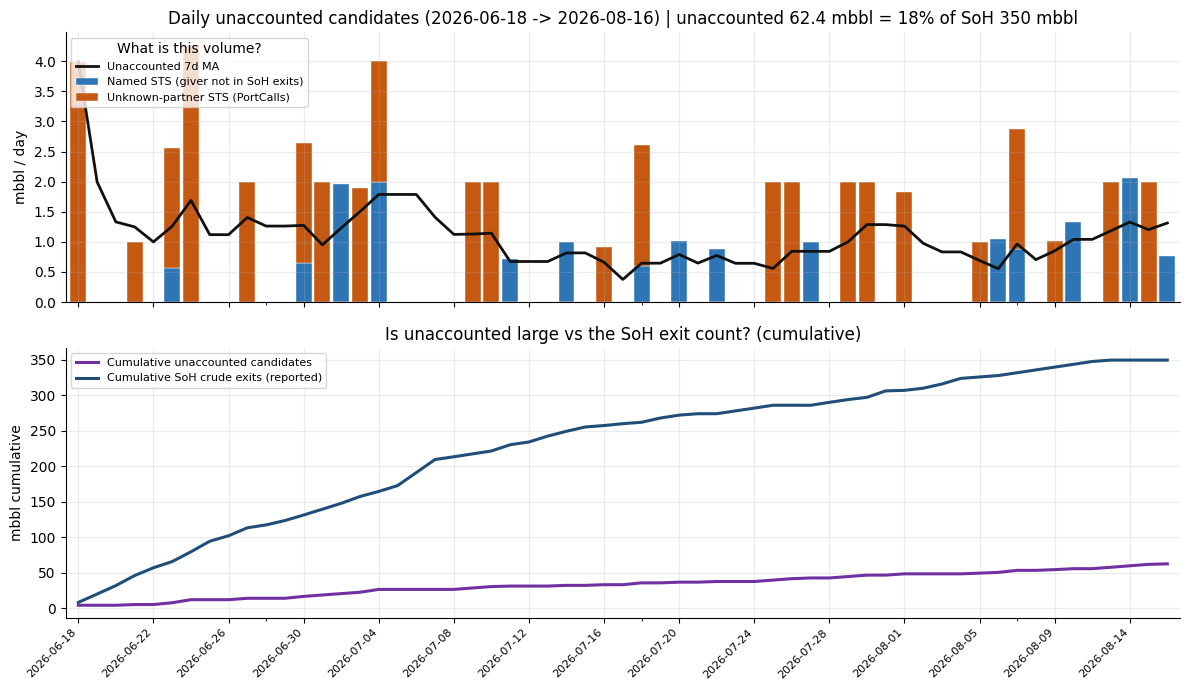

Wrote goo_sts_unaccounted_hormuz.csv (48 events), goo_sts_unaccounted_hormuz_ts.csv, goo_sts_named_giver_not_soh.csv (21 named_sts_giver_not_soh rows)


,event_date,event_ts,component,vessel,vessel_imo,counterparty,counterparty_imo,sts_zone,grade,origin_bucket,volume_bbl,notes
27,2026-08-16,2026-08-16 18:18:00,named_sts_giver_not_soh,Renad,9310161,Aljalaa,9343338.0,Sohar Light,NaN,unknown,51809,Giver not in SoH exits; receiver also not a known So...
28,2026-08-16,2026-08-16 18:18:00,named_sts_giver_not_soh,Renad,9310161,Aljalaa,9343338.0,Sohar Light,Khafji,unknown,8944,Giver not in SoH exits; receiver also not a known So...
29,2026-08-16,2026-08-16 02:39:00,named_sts_giver_not_soh,Ocean Loyalty,9375238,Gulf Loyalty,9441245.0,Sohar Light,ME,unknown,708798,Giver not in SoH exits; receiver also not a known So...
0,2026-08-15,2026-08-15 00:00:00,unknown_partner_not_soh,Olympic Life,9844277,None,NaN,Gulf of Oman,ME,unknown_mother,2000002,PortCall is_sts with no ShipToShips pair; receiver n...
30,2026-08-14,2026-08-14 20:17:00,named_sts_giver_not_soh,Takaoka,9478664,Caribbean Loyalty,9501150.0,Sohar Light,ME,unknown,2000002,Giver not in SoH exits; receiver also not a known So...
31,2026-08-14,2026-08-14 02:19:00,named_sts_giver_not_soh,Aljalaa,9343338,Navara,9241798.0,Sohar Light,NaN,unknown,51809,Giver not in SoH exits; receiver also not a known So...
32,2026-08-14,2026-08-14 02:19:00,named_sts_giver_not_soh,Aljalaa,9343338,Navara,9241798.0,Sohar Light,Khafji,unknown,8944,Giver not in SoH exits; receiver also not a known So...
1,2026-08-13,2026-08-13 00:00:00,unknown_partner_not_soh,Advantage Verdict,9933535,None,NaN,Gulf of Oman,ME,unknown_mother,2000002,PortCall is_sts with no ShipToShips pair; receiver n...
34,2026-08-10,2026-08-10 06:53:00,named_sts_giver_not_soh,Seaway,9273650,Albi,9444821.0,Fujairah Light,Jones Creek,unknown,22127,Giver not in SoH exits; receiver also not a known So...
33,2026-08-10,2026-08-10 06:53:00,named_sts_giver_not_soh,Seaway,9273650,Albi,9444821.0,Fujairah Light,Meleck,unknown,22127,Giver not in SoH exits; receiver also not a known So...


In [15]:
# --- Component A: unknown-partner PortCalls (receiver not in SoH exits) ---
rows = []

if "unknown_partner_sts" in dir() and len(unknown_partner_sts):
    up = unknown_partner_sts.copy()
    # PortCalls volumes can flip sign; treat as magnitude for inventory math
    up["vol_bbl"] = up["pc_volume_bbl"].abs()
    up_a = up[~up["receiver_in_soh_exits"]].copy()
    for _, r in up_a.iterrows():
        rows.append({
            "event_date": pd.Timestamp(r["start"]).normalize() if pd.notna(r["start"]) else pd.NaT,
            "event_ts": r["start"],
            "component": "unknown_partner_not_soh",
            "vessel": r.get("vessel_name"),
            "vessel_imo": r.get("vessel_imo"),
            "counterparty": None,
            "counterparty_imo": None,
            "sts_zone": r.get("sts_zone"),
            "grade": r.get("closest_ancestor_grade"),
            "origin_bucket": "unknown_mother",
            "volume_bbl": r["vol_bbl"],
            "notes": "PortCall is_sts with no ShipToShips pair; receiver not in SoH exits",
        })

# --- Component B: named STS, giver not in SoH exits, not east-coast load ---
# IMPORTANT: if the *receiver* already exited SoH (e.g. Cameroon/Bahrain Prosperity),
# do NOT put that row in primary unaccounted — those daughters are already in the crossing count.
# Keep them in a review bucket only (not in the bearish decision total).
if "unmatched_sts" in dir() and len(unmatched_sts):
    um = unmatched_sts.copy()
    if "origin_bucket" not in um.columns:
        um["origin_bucket"] = "unknown"
    if "receiver_in_soh_exits" not in um.columns:
        # Fallback if section 5 was not re-run with the new flag
        hist = crude_exit_imos_hist if "crude_exit_imos_hist" in dir() else exit_imos
        um["receiver_in_soh_exits"] = um["discharge_vessel_imo"].isin(hist)

    um_base = um[um["origin_bucket"] != "east_coast_load"].copy()
    um_base["vol_bbl"] = um_base["sts_volume_bbl"].abs()

    # Primary: giver not SoH AND receiver also not a known SoH exit
    um_b = um_base[~um_base["receiver_in_soh_exits"]].copy()
    # Review only: giver not in window exits, but receiver already exited (Prosperity-class)
    um_recv_exited = um_base[um_base["receiver_in_soh_exits"]].copy()

    for _, r in um_b.iterrows():
        rows.append({
            "event_date": pd.Timestamp(r["start"]).normalize() if pd.notna(r["start"]) else pd.NaT,
            "event_ts": r["start"],
            "component": "named_sts_giver_not_soh",
            "vessel": r.get("load_vessel_name"),
            "vessel_imo": r.get("load_vessel_imo"),
            "counterparty": r.get("discharge_vessel_name"),
            "counterparty_imo": r.get("discharge_vessel_imo"),
            "sts_zone": r.get("sts_zone"),
            "grade": r.get("closest_ancestor_grade", r.get("grade")),
            "origin_bucket": r.get("origin_bucket"),
            "volume_bbl": r["vol_bbl"],
            "notes": "Giver not in SoH exits; receiver also not a known SoH exit; excl. east-coast load",
        })

    review_recv_exited_mbbl = float(um_recv_exited["vol_bbl"].sum() / 1e6) if len(um_recv_exited) else 0.0
    print(
        f"Named STS excluded from unaccounted (receiver already SoH-exited): "
        f"{len(um_recv_exited):,} events, {review_recv_exited_mbbl:,.2f} mbbl"
    )
    if len(um_recv_exited):
        show_cols = [c for c in [
            "start", "load_vessel_name", "load_vessel_imo",
            "discharge_vessel_name", "discharge_vessel_imo",
            "sts_zone", "sts_volume_bbl", "origin_bucket",
        ] if c in um_recv_exited.columns]
        print("Examples (receiver already exited — NOT in primary unaccounted):")
        display(um_recv_exited[show_cols].sort_values("start", ascending=False).head(10))

unaccounted = pd.DataFrame(rows)
if len(unaccounted) == 0:
    unaccounted = pd.DataFrame(columns=[
        "event_date", "event_ts", "component", "vessel", "vessel_imo",
        "counterparty", "counterparty_imo",
        "sts_zone", "grade", "origin_bucket", "volume_bbl", "notes",
    ])

unaccounted_mbbl = float(unaccounted["volume_bbl"].fillna(0).sum() / 1e6) if len(unaccounted) else 0.0
by_comp = (
    unaccounted.groupby("component")["volume_bbl"].sum().div(1e6).round(2)
    if len(unaccounted) else pd.Series(dtype=float)
)
share_of_soh = (unaccounted_mbbl / soh_crude_mbbl) if soh_crude_mbbl else float("nan")

# Daily timeseries (stacked components)
if len(unaccounted):
    ts = (
        unaccounted.dropna(subset=["event_date"])
        .groupby(["event_date", "component"], as_index=False)["volume_bbl"]
        .sum()
    )
    ts["mbbl"] = ts["volume_bbl"] / 1e6
    ts_pivot = (
        ts.pivot(index="event_date", columns="component", values="mbbl")
        .fillna(0)
        .sort_index()
    )
    ts_pivot["unaccounted_total_mbbl"] = ts_pivot.sum(axis=1)
    # Align calendar to SoH daily exits for visual compare
    soh_daily = (
        crude_exits.assign(day=crude_exits["Crossing Date"].dt.normalize())
        .groupby("day")["volume_bbl"]
        .sum()
        .div(1e6)
        .rename("soh_exit_mbbl")
    )
    unaccounted_ts = ts_pivot.join(soh_daily, how="outer").fillna(0).sort_index()
else:
    unaccounted_ts = pd.DataFrame(columns=["unaccounted_total_mbbl", "soh_exit_mbbl"])

print("=== Unaccounted Hormuz candidates ===")
print(f"SOH crude exits (reported):     {soh_crude_mbbl:,.2f} mbbl")
print(f"Unaccounted candidate total:    {unaccounted_mbbl:,.2f} mbbl  ({share_of_soh:.1%} of SoH exits)")
print("By component (mbbl):")
print(by_comp.to_string() if len(by_comp) else "  (none)")
print()

# Simple decision cue thresholds (tunable)
SOFT_SHARE = 0.05   # <5% of SoH -> count looks fine
HARD_SHARE = 0.15   # >15% -> material gap worth treating as bearish risk
if pd.isna(share_of_soh):
    verdict = "n/a"
elif share_of_soh < SOFT_SHARE:
    verdict = (
        f"COUNT LOOKS OK — unaccounted is only {share_of_soh:.1%} of reported SoH exits "
        f"(<{SOFT_SHARE:.0%} soft threshold)."
    )
elif share_of_soh < HARD_SHARE:
    verdict = (
        f"WATCH — unaccounted is {share_of_soh:.1%} of SoH exits "
        f"(between {SOFT_SHARE:.0%} and {HARD_SHARE:.0%}); review event list before calling."
    )
else:
    verdict = (
        f"BEARISH CUE — unaccounted is {share_of_soh:.1%} of SoH exits "
        f"(>{HARD_SHARE:.0%}); possible missed dark exits / undercount vs crossings."
    )
print("Verdict:", verdict)

# --- Plot helper: stacked bars + easy start/end date toggle ---
COMP_COLORS = {
    "named_sts_giver_not_soh": "#2e75b6",
    "unknown_partner_not_soh": "#c65911",
}


def plot_unaccounted(
    start_date=None,
    end_date=None,
    ts: pd.DataFrame | None = None,
    show_soh: bool = True,
    ma_window: int = 7,
    figsize=(12, 7),
):
    """
    Top: stacked unaccounted bars + MA (composition / pace).
    Bottom: cumulative unaccounted vs SoH exits (scale comparison).

    SoH daily exits are intentionally NOT on the top panel (dual-axis was misleading).
    Window totals vs SoH are shown in the title / printout instead.

    Toggle without re-pulling Kpler:
        plot_unaccounted(start_date="2026-07-01")
        plot_unaccounted(start_date=date(2026, 7, 15), end_date=date(2026, 8, 5))
    """
    data = (ts if ts is not None else unaccounted_ts).copy()
    if data is None or len(data) == 0:
        print("No unaccounted_ts to plot.")
        return None

    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)

    # Component cols on full series (for MA continuity before window start)
    all_comp = [c for c in data.columns if c not in ("unaccounted_total_mbbl", "soh_exit_mbbl")]
    preferred = ["named_sts_giver_not_soh", "unknown_partner_not_soh"]
    all_comp = [c for c in preferred if c in all_comp] + [c for c in all_comp if c not in preferred]
    if all_comp:
        data["unaccounted_total_mbbl"] = data[all_comp].sum(axis=1)
    else:
        data["unaccounted_total_mbbl"] = 0.0
    # Rolling MA on full history so toggled windows keep a proper trailing average
    data["unaccounted_ma"] = (
        data["unaccounted_total_mbbl"].rolling(ma_window, min_periods=1).mean()
    )

    lo = pd.Timestamp(start_date) if start_date is not None else data.index.min()
    hi = pd.Timestamp(end_date) if end_date is not None else data.index.max()
    if end_date is not None:
        hi = pd.Timestamp(end_date) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    view = data.loc[(data.index >= lo) & (data.index <= hi)].copy()
    if len(view) == 0:
        print(f"No rows between {lo.date()} and {pd.Timestamp(hi).date()}.")
        return None

    comp_cols = [c for c in preferred if c in view.columns] + [
        c for c in all_comp if c in view.columns and c not in preferred
    ]
    colors = [COMP_COLORS.get(c, "#7f7f7f") for c in comp_cols]

    window_unacc = float(view[comp_cols].sum().sum()) if comp_cols else 0.0
    window_soh = float(view["soh_exit_mbbl"].sum()) if "soh_exit_mbbl" in view.columns else 0.0
    print(
        f"Plot window: {view.index.min().date()} -> {view.index.max().date()} | "
        f"unaccounted={window_unacc:,.2f} mbbl | SoH exits={window_soh:,.2f} mbbl"
        + (f" ({window_unacc / window_soh:.1%} of SoH)" if window_soh else "")
        + f" | MA={ma_window}d"
    )

    share_txt = (
        f" | unaccounted {window_unacc:.1f} mbbl = {window_unacc / window_soh:.0%} of SoH {window_soh:.0f} mbbl"
        if window_soh
        else f" | unaccounted {window_unacc:.1f} mbbl"
    )

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    x = range(len(view))

    # Top: ONLY unaccounted composition (stacked bars + MA) — easy to read
    ax = axes[0]
    if comp_cols:
        label_map = {
            "named_sts_giver_not_soh": "Named STS (giver not in SoH exits)",
            "unknown_partner_not_soh": "Unknown-partner STS (PortCalls)",
        }
        plot_df = view[comp_cols].rename(columns=label_map)
        plot_df.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            width=0.85,
            color=colors,
            edgecolor="white",
            linewidth=0.3,
        )
    ax.plot(
        x,
        view["unaccounted_ma"].values,
        color="#111111",
        lw=2.0,
        label=f"Unaccounted {ma_window}d MA",
        zorder=5,
    )
    ax.set_ylabel("mbbl / day")
    ax.set_title(
        "Daily unaccounted candidates"
        f" ({view.index.min().date()} -> {view.index.max().date()}){share_txt}"
    )
    ax.legend(fontsize=8, loc="upper left", title="What is this volume?")
    # Friendly legend aliases if default col names are cryptic
    # (matplotlib already used column names; relabel via text note below title)

    # Bottom: scale check — unaccounted vs reported SoH exits (same units)
    ax = axes[1]
    ax.plot(
        x,
        view["unaccounted_total_mbbl"].cumsum().values,
        color="#7030a0",
        lw=2.2,
        label="Cumulative unaccounted candidates",
    )
    if show_soh and "soh_exit_mbbl" in view.columns:
        ax.plot(
            x,
            view["soh_exit_mbbl"].cumsum().values,
            color="#1f4e79",
            lw=2.2,
            label="Cumulative SoH crude exits (reported)",
        )
    ax.set_ylabel("mbbl cumulative")
    ax.set_title("Is unaccounted large vs the SoH exit count? (cumulative)")
    ax.legend(fontsize=8, loc="upper left")

    # Readable date ticks
    n = len(view)
    step = max(1, n // 12)
    ticks = list(range(0, n, step))
    labels = [view.index[i].strftime("%Y-%m-%d") for i in ticks]
    for a in axes:
        a.set_xticks(ticks)
        a.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

    fig.tight_layout()
    plt.show()
    return view


# Default plot = analysis START_DATE through latest
# Re-run with other windows, e.g. plot_unaccounted("2026-07-01") or plot_unaccounted(date(2026,7,15), date(2026,8,5))
_ = plot_unaccounted(start_date=START_DATE)

# Persist event-level + timeseries
unaccounted.to_csv(OUT_UNACCOUNTED, index=False)
unaccounted_ts.to_csv(OUT_UNACCOUNTED_TS)
named_giver = unaccounted[unaccounted["component"] == "named_sts_giver_not_soh"].copy()
named_giver.to_csv(OUT_NAMED_GIVER_NOT_SOH, index=False)
print(f"Wrote {OUT_UNACCOUNTED.name} ({len(unaccounted):,} events), {OUT_UNACCOUNTED_TS.name}, "
      f"{OUT_NAMED_GIVER_NOT_SOH.name} ({len(named_giver):,} named_sts_giver_not_soh rows)")
display(unaccounted.sort_values("event_ts", ascending=False).head(20))


### Toggle plot window

Change `PLOT_START` / `PLOT_END` and re-run this cell only (no Kpler re-pull).


Plot window: 2026-06-18 -> 2026-08-16 | unaccounted=62.39 mbbl | SoH exits=349.58 mbbl (17.8% of SoH) | MA=7d


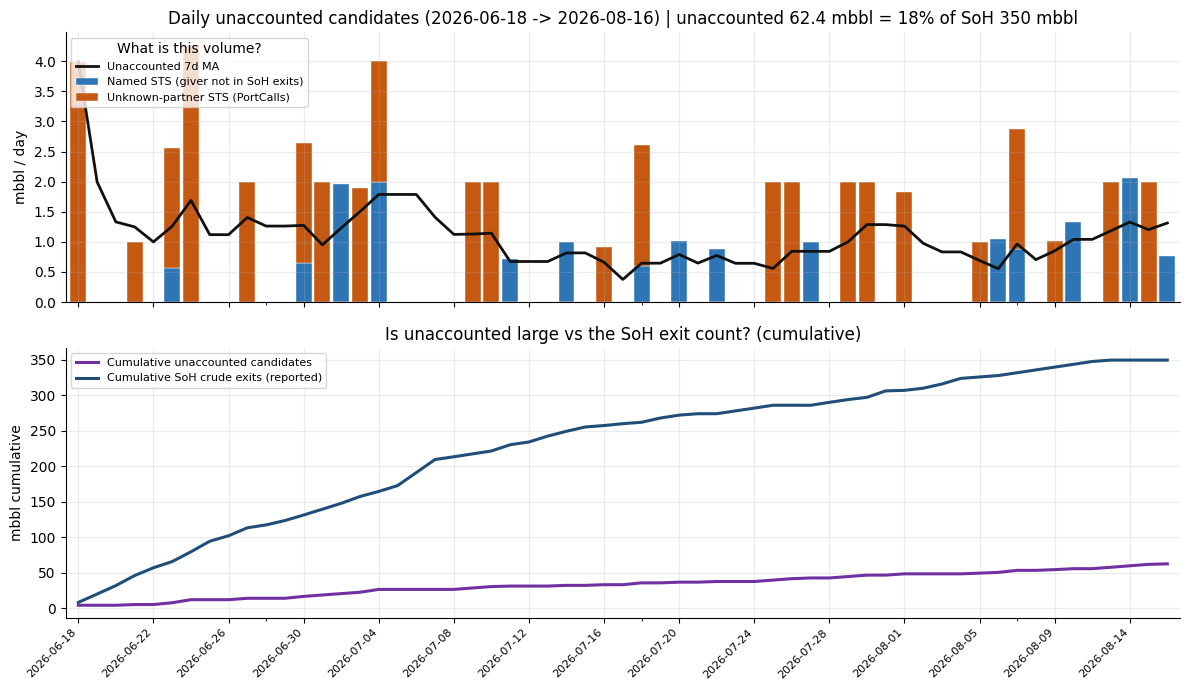

In [16]:
# Examples — edit and re-run:
PLOT_START = START_DATE          # or "2026-07-01" or date(2026, 7, 15)
PLOT_END = None                  # or "2026-08-05"
MA_WINDOW = 7                    # moving average on daily unaccounted total

_ = plot_unaccounted(start_date=PLOT_START, end_date=PLOT_END, ma_window=MA_WINDOW)


## 9. Summary — is SoH undercounting?

Primary answer lives in **§8c** (`unaccounted_mbbl` vs `soh_crude_mbbl` + verdict).

Supporting detail below:
- **Matched regional STS** after an SoH exit -> already in SoH count (not additive).
- **Unmatched named STS + east-coast load** -> exclude.
- **Unmatched named STS + hormuz/unknown origin** -> feeds unaccounted (component B).
- **Unknown-partner PortCall STS, receiver not in SoH exits** -> feeds unaccounted (component A).
- **Unknown-partner, receiver already SoH exit** -> dark signal only, not extra strait volume.


In [17]:
matched_sts_mbbl = _mbbl(sts_region[sts_region["load_vessel_imo"].isin(exit_imos)])
unmatched_total_mbbl = _mbbl(unmatched_sts)
unmatched_east_mbbl = _mbbl(unmatched_sts[unmatched_sts["origin_bucket"] == "east_coast_load"])
unmatched_hormuz_mbbl = _mbbl(unmatched_sts[unmatched_sts["origin_bucket"] == "hormuz_side_load"])
unmatched_unknown_mbbl = _mbbl(unmatched_sts[unmatched_sts["origin_bucket"] == "unknown"])

soh_with_sts_mbbl = journeys_df.loc[journeys_df["chain_has_sts"], "exit_volume_bbl"].sum() / 1e6
soh_no_sts_mbbl = journeys_df.loc[~journeys_df["chain_has_sts"], "exit_volume_bbl"].sum() / 1e6
soh_east_origin_mbbl = journeys_df.loc[journeys_df["origin_bucket"] == "east_coast_load", "exit_volume_bbl"].sum() / 1e6
soh_hormuz_origin_mbbl = journeys_df.loc[journeys_df["origin_bucket"] == "hormuz_side_load", "exit_volume_bbl"].sum() / 1e6

# Comparable SoH baseline: crude exits whose cargo origin is not an east-coast loading
soh_comparable_mbbl = journeys_df.loc[
    journeys_df["origin_bucket"] != "east_coast_load", "exit_volume_bbl"
].sum() / 1e6

# Undercount candidate = unmatched STS not explained by east-coast loadings
undercount_candidate_mbbl = unmatched_hormuz_mbbl + unmatched_unknown_mbbl

# Unknown-partner PortCall STS (from section 8b) — dark mother candidates
unknown_partner_mbbl = _mbbl(unknown_partner_sts, "pc_volume_bbl") if "unknown_partner_sts" in dir() else 0.0
unknown_partner_also_soh_mbbl = (
    _mbbl(unknown_partner_sts[unknown_partner_sts["receiver_in_soh_exits"]], "pc_volume_bbl")
    if "unknown_partner_sts" in dir() and "receiver_in_soh_exits" in unknown_partner_sts.columns
    else 0.0
)
unknown_partner_not_soh_mbbl = unknown_partner_mbbl - unknown_partner_also_soh_mbbl

summary = pd.DataFrame([
    {"metric": "SOH crude exit volume (all)", "mbbl": soh_crude_mbbl, "notes": f"{START_DATE} -> {end}"},
    {"metric": "UNACCOUNTED Hormuz candidates (primary)", "mbbl": unaccounted_mbbl if "unaccounted_mbbl" in dir() else float("nan"), "notes": "§8c decision metric"},
    {"metric": "Unaccounted / SoH exits (%)", "mbbl": (share_of_soh * 100) if "share_of_soh" in dir() and pd.notna(share_of_soh) else float("nan"), "notes": "value is percent share, not mbbl"},
    {"metric": "SOH exits excl. east-coast load origin", "mbbl": soh_comparable_mbbl, "notes": "comparable Hormuz flow"},
    {"metric": "SOH exits with east-coast load origin", "mbbl": soh_east_origin_mbbl, "notes": "loaded east of strait; review shuttles"},
    {"metric": "Regional STS total (all zones)", "mbbl": _mbbl(sts_region), "notes": "Fujairah/Sohar/GoO named pairs"},
    {"metric": "STS with load IMO in SoH exits", "mbbl": matched_sts_mbbl, "notes": "downstream of counted exits; not additive"},
    {"metric": "Unmatched STS — east-coast load origin", "mbbl": unmatched_east_mbbl, "notes": "exclude from SoH compare"},
    {"metric": "Unmatched STS — hormuz-side load origin", "mbbl": unmatched_hormuz_mbbl, "notes": "undercount candidate"},
    {"metric": "Unmatched STS — unknown origin", "mbbl": unmatched_unknown_mbbl, "notes": "undercount candidate / review"},
    {"metric": "Undercount candidate (hormuz+unknown unmatched)", "mbbl": undercount_candidate_mbbl, "notes": "named ShipToShips only"},
    {"metric": "Unknown-partner PortCall STS (total)", "mbbl": unknown_partner_mbbl, "notes": "is_sts with no ShipToShips pair"},
    {"metric": "Unknown-partner — receiver also SoH exit", "mbbl": unknown_partner_also_soh_mbbl, "notes": "dark signal; not additive to SoH"},
    {"metric": "Unknown-partner — receiver NOT in SoH exits", "mbbl": unknown_partner_not_soh_mbbl, "notes": "strongest SoH undercount candidate"},
    {"metric": "SOH exit volume that later STS", "mbbl": soh_with_sts_mbbl, "notes": f"lag<={STS_LAG_DAYS}d; attributed once"},
    {"metric": "SOH exit volume with no STS hop", "mbbl": soh_no_sts_mbbl, "notes": "direct sail-away or STS outside pull"},
])

print(summary.to_string(index=False))
print()
if undercount_candidate_mbbl > 0.5:
    print(
        f"Verdict cue: ~{undercount_candidate_mbbl:.1f} mbbl unmatched STS is not explained by east-coast loadings "
        f"— investigate before treating SOH as complete."
    )
else:
    print(
        "Verdict cue: little unmatched non-east-coast STS vs SoH exits — "
        "downstream STS looks consistent with the crossing count (for this window/lag)."
    )

if "verdict" in dir():
    print("Primary verdict (§8c):", verdict)

summary


                                         metric       mbbl                                     notes
                    SOH crude exit volume (all) 349.580339                  2026-06-17 -> 2026-08-16
        UNACCOUNTED Hormuz candidates (primary)  62.386900                       §8c decision metric
                    Unaccounted / SoH exits (%)  17.846227          value is percent share, not mbbl
         SOH exits excl. east-coast load origin 349.580339                    comparable Hormuz flow
          SOH exits with east-coast load origin   0.000000    loaded east of strait; review shuttles
                 Regional STS total (all zones) 186.259884            Fujairah/Sohar/GoO named pairs
                 STS with load IMO in SoH exits   9.027159 downstream of counted exits; not additive
         Unmatched STS — east-coast load origin  31.070604                  exclude from SoH compare
        Unmatched STS — hormuz-side load origin  19.643330                      undercount 

,metric,mbbl,notes
0,SOH crude exit volume (all),349.580339,2026-06-17 -> 2026-08-16
1,UNACCOUNTED Hormuz candidates (primary),62.386900,§8c decision metric
2,Unaccounted / SoH exits (%),17.846227,"value is percent share, not mbbl"
3,SOH exits excl. east-coast load origin,349.580339,comparable Hormuz flow
4,SOH exits with east-coast load origin,0.000000,loaded east of strait; review shuttles
5,Regional STS total (all zones),186.259884,Fujairah/Sohar/GoO named pairs
6,STS with load IMO in SoH exits,9.027159,downstream of counted exits; not additive
7,Unmatched STS — east-coast load origin,31.070604,exclude from SoH compare
8,Unmatched STS — hormuz-side load origin,19.643330,undercount candidate
9,Unmatched STS — unknown origin,126.518791,undercount candidate / review


In [18]:
cols_show = [c for c in [
    "start", "sts_zone", "load_vessel_name", "load_vessel_imo",
    "discharge_vessel_name", "discharge_vessel_imo", "sts_volume_bbl",
    "closest_ancestor_grade", "origin", "origin_bucket",
] if c in unmatched_sts.columns]

print("Unmatched STS — undercount candidates (excl. east-coast load origin):")
cand = unmatched_sts[unmatched_sts["origin_bucket"] != "east_coast_load"]
display(cand[cols_show].sort_values("start", ascending=False).head(25))

print("\nUnmatched STS — east-coast load origin (excluded from SoH compare):")
display(
    unmatched_sts.loc[unmatched_sts["origin_bucket"] == "east_coast_load", cols_show]
    .sort_values("start", ascending=False)
    .head(15)
)

sts_region.to_csv(OUT_STS, index=False)
journeys_df.to_csv(OUT_JOURNEYS, index=False)
summary.to_csv(OUT_SUMMARY, index=False)
if "unknown_partner_sts" in dir():
    unknown_partner_sts.to_csv(OUT_UNKNOWN_STS, index=False)
print(f"Wrote {OUT_STS.name}, {OUT_JOURNEYS.name}, {OUT_SUMMARY.name}" + (f", {OUT_UNKNOWN_STS.name}" if "unknown_partner_sts" in dir() else ""))


Unmatched STS — undercount candidates (excl. east-coast load origin):


,start,sts_zone,load_vessel_name,load_vessel_imo,discharge_vessel_name,discharge_vessel_imo,sts_volume_bbl,closest_ancestor_grade,origin,origin_bucket
0,2026-08-16 18:18:00,Sohar Light,Renad,9310161,Aljalaa,9343338,51809,NaN,None,unknown
1,2026-08-16 18:18:00,Sohar Light,Renad,9310161,Aljalaa,9343338,8944,Khafji,None,unknown
2,2026-08-16 03:39:00,Fujairah Light,Ocean Lily,9284960,Rotterdam Energy,9508859,1986831,Zakum,Mina Al Fahal,hormuz_side_load
3,2026-08-16 02:39:00,Sohar Light,Ocean Loyalty,9375238,Gulf Loyalty,9441245,708798,ME,None,unknown
4,2026-08-15 00:00:00,Sohar Light,Vive Ut Vivas,1055387,Togo Prosperity,9411032,2000002,ME,None,unknown
5,2026-08-15 00:00:00,Fujairah Light,New Dragon,9379715,Cyprus Prosperity,9595216,992444,Zakum,None,unknown
6,2026-08-15 00:00:00,Fujairah Light,New Dragon,9379715,Cyprus Prosperity,9595216,992444,Umm Lulu,None,unknown
7,2026-08-15 00:00:00,Fujairah Light,Dht Taiga,9590888,Angola B,9623685,1959999,Basrah,None,unknown
8,2026-08-15 00:00:00,Sohar Light,Degas,9926673,Egypt Prosperity,9534004,1959999,Basrah,None,unknown
10,2026-08-14 20:17:00,Sohar Light,Takaoka,9478664,Caribbean Loyalty,9501150,2000002,ME,None,unknown



Unmatched STS — east-coast load origin (excluded from SoH compare):


,start,sts_zone,load_vessel_name,load_vessel_imo,discharge_vessel_name,discharge_vessel_imo,sts_volume_bbl,closest_ancestor_grade,origin,origin_bucket
9,2026-08-15 00:00:00,Fujairah Light,Australis,9875783,Fujairah Energy,9723071,2000002,ME,ADCOP Fujairah,east_coast_load
17,2026-08-10 11:59:00,Fujairah Light,Sargodha,9360465,Ocean Loyalty,9375238,722655,Zakum,ADCOP Fujairah,east_coast_load
24,2026-08-09 19:37:00,Fujairah Light,P.Aliki,9460136,Ocean Loyalty,9375238,705924,Zakum,Fujairah,east_coast_load
25,2026-08-09 00:00:00,Fujairah Light,Desh Viraat,9371593,Dar Salwa,9534779,2000002,ME,ADCOP Fujairah,east_coast_load
28,2026-08-07 00:00:00,Fujairah Light,Maran Mars,9858046,Al Bahyah,9937799,1996002,Umm Lulu,ADCOP Fujairah,east_coast_load
40,2026-08-02 18:39:00,Fujairah Light,Antigua I,9753363,Singapore Prosperity,9419967,959592,ME,ADCOP Fujairah,east_coast_load
42,2026-08-01 22:18:00,Fujairah Light,Desh Abhimaan,9326809,Singapore Prosperity,9419967,1040410,ME,ADCOP Fujairah,east_coast_load
44,2026-07-31 00:00:00,Sohar Light,Olympus,9941661,France C,9322281,1999996,Zakum,ADCOP Fujairah,east_coast_load
51,2026-07-26 00:00:00,Fujairah Light,Nave Synergy,9513763,Fujairah Energy,9723071,1040605,Basrah Med.,ADCOP Fujairah,east_coast_load
52,2026-07-26 00:00:00,Fujairah Light,Nave Synergy,9513763,Fujairah Energy,9723071,1009395,Fateh,ADCOP Fujairah,east_coast_load


Wrote goo_sts_raw.csv, goo_sts_journeys.csv, goo_sts_vs_soh_summary.csv, goo_sts_unknown_partner.csv


## 10. Visualizations

Volume and structure checks: STS by zone over time, SoH vs STS comparison (incl. unknown-partner), exit->STS lag, and origin buckets (loadings, not STS zones).


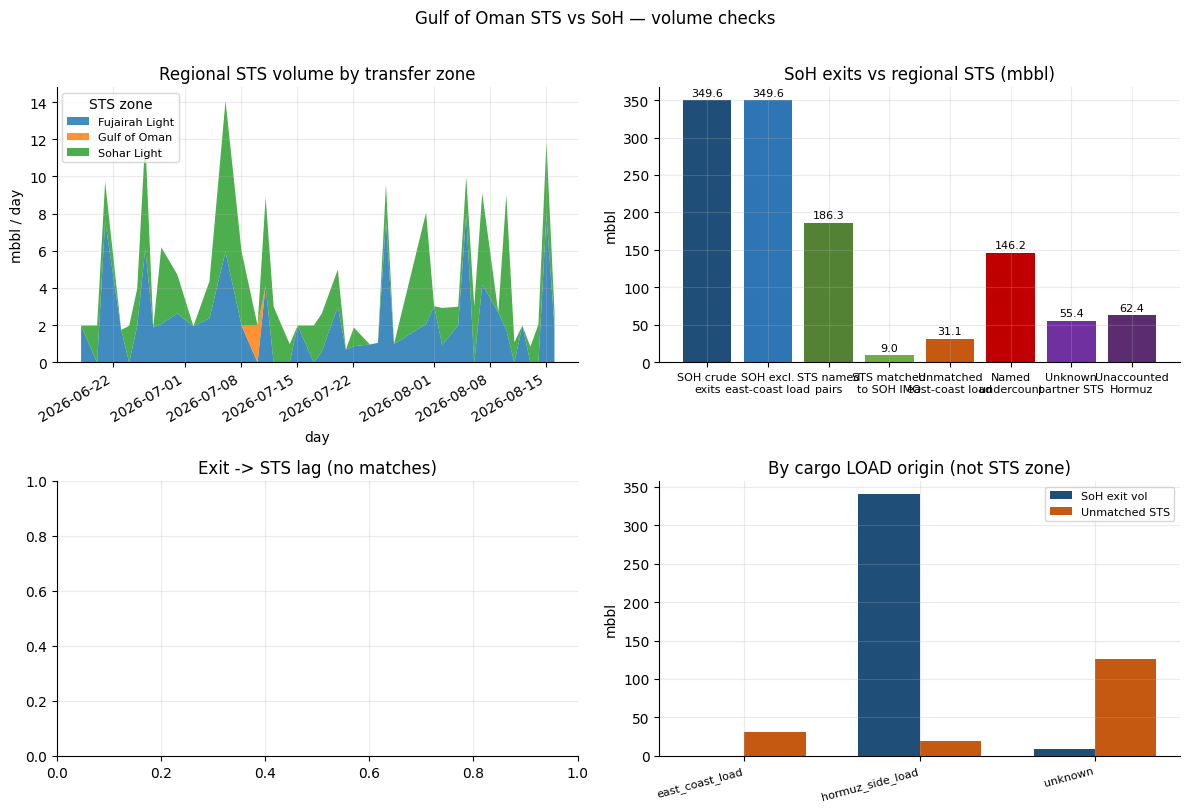

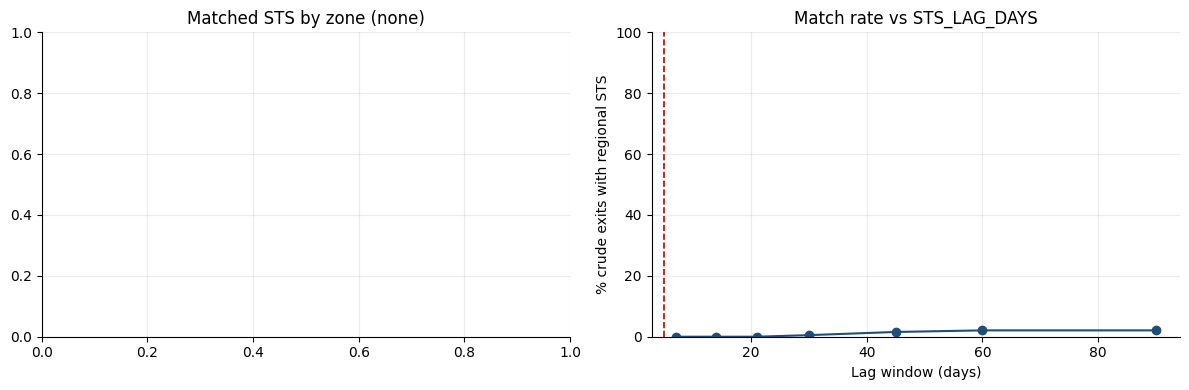

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1) Daily STS volume by zone (stacked)
ax = axes[0, 0]
daily_zone = (
    sts_region.assign(day=sts_region["start"].dt.floor("D"))
    .groupby(["day", "sts_zone"], as_index=False)["sts_volume_bbl"]
    .sum()
)
if len(daily_zone):
    pivot = daily_zone.pivot(index="day", columns="sts_zone", values="sts_volume_bbl").fillna(0) / 1e6
    pivot.plot(kind="area", stacked=True, ax=ax, alpha=0.85, linewidth=0)
    ax.set_title("Regional STS volume by transfer zone")
    ax.set_ylabel("mbbl / day")
    ax.legend(title="STS zone", fontsize=8, loc="upper left")
else:
    ax.set_title("Regional STS volume (no data)")

# 2) Headline bars: SoH vs STS splits
ax = axes[0, 1]
bar_labels = [
    "SOH crude\nexits",
    "SOH excl.\neast-coast load",
    "STS named\npairs",
    "STS matched\nto SOH IMO",
    "Unmatched\neast-coast load",
    "Named\nundercount",
    "Unknown\npartner STS",
    "Unaccounted\nHormuz",
]
bar_vals = [
    soh_crude_mbbl,
    soh_comparable_mbbl,
    _mbbl(sts_region),
    matched_sts_mbbl,
    unmatched_east_mbbl,
    undercount_candidate_mbbl,
    unknown_partner_mbbl if "unknown_partner_mbbl" in dir() else 0.0,
    unaccounted_mbbl if "unaccounted_mbbl" in dir() else 0.0,
]
colors = ["#1f4e79", "#2e75b6", "#548235", "#70ad47", "#c65911", "#c00000", "#7030a0", "#5b2c6f"]
ax.bar(range(len(bar_labels)), bar_vals, color=colors)
ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_ylabel("mbbl")
ax.set_title("SoH exits vs regional STS (mbbl)")
for i, v in enumerate(bar_vals):
    ax.text(i, v + max(bar_vals) * 0.01, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

# 3) Lag histogram for matched exit->STS
ax = axes[1, 0]
if len(matched_only) and matched_only["sts_lag_days"].notna().any():
    ax.hist(matched_only["sts_lag_days"].dropna(), bins=15, color="#2e75b6", edgecolor="white")
    ax.axvline(STS_LAG_DAYS, color="#c00000", ls="--", lw=1.2, label=f"STS_LAG_DAYS={STS_LAG_DAYS}")
    ax.set_xlabel("Days from SoH exit to STS")
    ax.set_ylabel("STS events")
    ax.set_title("Exit -> STS lag (matched)")
    ax.legend(fontsize=8)
else:
    ax.set_title("Exit -> STS lag (no matches)")

# 4) Origin buckets: journeys (SoH) vs unmatched STS
ax = axes[1, 1]
j_orig = journeys_df.groupby("origin_bucket")["exit_volume_bbl"].sum().div(1e6)
u_orig = unmatched_sts.groupby("origin_bucket")["sts_volume_bbl"].sum().div(1e6)
buckets = sorted(set(j_orig.index) | set(u_orig.index))
x = np.arange(len(buckets))
w = 0.35
ax.bar(x - w / 2, [j_orig.get(b, 0) for b in buckets], width=w, label="SoH exit vol", color="#1f4e79")
ax.bar(x + w / 2, [u_orig.get(b, 0) for b in buckets], width=w, label="Unmatched STS", color="#c65911")
ax.set_xticks(x)
ax.set_xticklabels(buckets, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("mbbl")
ax.set_title("By cargo LOAD origin (not STS zone)")
ax.legend(fontsize=8)

fig.suptitle("Gulf of Oman STS vs SoH — volume checks", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

# Extra: matched STS share by zone + lag sweep line
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

ax = axes2[0]
if len(matched_only):
    by_z = matched_only.groupby("sts_zone")["sts_volume_bbl"].sum().div(1e6).sort_values(ascending=True)
    by_z.plot(kind="barh", ax=ax, color="#548235")
    ax.set_xlabel("mbbl")
    ax.set_title("Matched SoH->STS volume by transfer zone")
else:
    ax.set_title("Matched STS by zone (none)")

ax = axes2[1]

def _match_rate(lag_days: int) -> float:
    hits = 0
    n = 0
    for _, ex in crude_exits.iterrows():
        imo = ex["IMO"]
        if pd.isna(imo):
            continue
        n += 1
        exit_dt = ex["Crossing Date"]
        lag_end = exit_dt + pd.Timedelta(days=lag_days)
        hit = sts_region[
            (sts_region["load_vessel_imo"] == int(imo))
            & (sts_region["start"] >= exit_dt)
            & (sts_region["start"] <= lag_end)
        ]
        if len(hit):
            hits += 1
    return hits / n if n else np.nan

lag_days_list = [7, 14, 21, 30, 45, 60, 90]
lag_shares = [_match_rate(d) * 100 for d in lag_days_list]
ax.plot(lag_days_list, lag_shares, marker="o", color="#1f4e79")
ax.axvline(STS_LAG_DAYS, color="#c00000", ls="--", lw=1.2)
ax.set_xlabel("Lag window (days)")
ax.set_ylabel("% crude exits with regional STS")
ax.set_title("Match rate vs STS_LAG_DAYS")
ax.set_ylim(0, 100)

fig2.tight_layout()
plt.show()


## 11. Optional: inspect lag sensitivity

If many known shuttles look unmatched, raise `STS_LAG_DAYS` (e.g. 60-90) and re-run from section 5. The table below recomputes match rates without re-pulling Kpler.


In [20]:
def match_rate_for_lag(lag_days: int) -> dict:
    hits = 0
    for _, ex in crude_exits.iterrows():
        imo = ex["IMO"]
        if pd.isna(imo):
            continue
        exit_dt = ex["Crossing Date"]
        lag_end = exit_dt + pd.Timedelta(days=lag_days)
        hit = sts_region[
            (sts_region["load_vessel_imo"] == int(imo))
            & (sts_region["start"] >= exit_dt)
            & (sts_region["start"] <= lag_end)
        ]
        if len(hit):
            hits += 1
    n = int(crude_exits["IMO"].notna().sum())
    return {"lag_days": lag_days, "exits_with_sts": hits, "crude_exits": n, "share": hits / n if n else np.nan}

lag_sweep = pd.DataFrame([match_rate_for_lag(d) for d in (7, 14, 21, 30, 45, 60, 90)])
lag_sweep["share_pct"] = (lag_sweep["share"] * 100).round(1)
lag_sweep


,lag_days,exits_with_sts,crude_exits,share,share_pct
0,7,0,192,0.000000,0.0
1,14,0,192,0.000000,0.0
2,21,0,192,0.000000,0.0
3,30,1,192,0.005208,0.5
4,45,3,192,0.015625,1.6
5,60,4,192,0.020833,2.1
6,90,4,192,0.020833,2.1
